# Voi Ch’Intrate: A Hybrid Probabilistic-Fuzzy Framework for Ambiguous Emotional State Classification Inspired by La Divina Commedia

In [ ]:
!pip install -q pypdf scikit-learn scikit-fuzzy pandas numpy matplotlib

from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import re
import csv
import math
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

BASE_DIR = Path("/content/drive/MyDrive/_Dante_")

RAW_DIR = BASE_DIR / "data_raw"
OUT_DIR = BASE_DIR / "data_processed"
CANTO_DIR = OUT_DIR / "cantos"
INFERNO_PDF = RAW_DIR / "Inferno.pdf"
PARADISO_PDF = RAW_DIR / "Paradiso.pdf"
PURGATORIO_PDF = RAW_DIR / "Purgatorio.pdf"

CANTO_DIR.mkdir(parents=True, exist_ok=True)

print("Inferno exists :", INFERNO_PDF.exists(), INFERNO_PDF)
print("Paradiso exists:", PARADISO_PDF.exists(), PARADISO_PDF)
print("Purgatorio exists :", PURGATORIO_PDF.exists(), PURGATORIO_PDF)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 30.9 MB/s eta 0:00:00
Mounted at /content/drive
Inferno exists : True /content/drive/MyDrive/_Dante_/data_raw/Inferno.pdf
Paradiso exists: True /content/drive/MyDrive/_Dante_/data_raw/Paradiso.pdf
Purgatorio exists : True /content/drive/MyDrive/_Dante_/data_raw/Purgatorio.pdf


**PDF to TXT + Splitting Canto**

In [ ]:
from pypdf import PdfReader

def normalize_text(s):
    s = s.replace("\ufb01", "fi").replace("\ufb02", "fl")
    s = s.replace("´", "'").replace("`", "'")
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def clean_poem_line(line):
    line = normalize_text(line)
    if "paskvil.com" in line.lower(): # buang URL/header/footer
        return None
    if "Dante Alighieri - Divine Comedy" in line:
        return None
    if line.startswith("Figure "):
        return None
    if line.startswith("Contents"):
        return None
    if line.startswith("Some rights reserved"):
        return None

    # buang nomor footnote di akhir baris
    line = re.sub(r"\s+\d+$", "", line).strip()

    # buang footnote yang biasanya diawali angka + teks panjang
    if re.match(r"^\d+[A-Za-z]", line):
        return None

    # buang baris terlalu panjang, biasanya catatan kaki/prosa
    if len(line) > 95:
        return None

    # buang baris kosong
    if not line:
        return None

    # buang baris metadata
    banned = [
        "DIVINE COMEDY",
        "DANTE ALIGHIERI",
        "HENRY WADSWORTH LONGFELLOW",
        "ENGLISH TRANSLATION",
        "ILLUSTRATIONS",
        "PDF PREPARATION",
        "Released under Creative Commons",
    ]
    if any(b.lower() in line.lower() for b in banned):
        return None

    return line

def detect_canto_starts(reader, cantica):
    starts = []

    for page_idx, page in enumerate(reader.pages):
        text = page.extract_text() or ""

        # Pola utama: Inferno\nCanto 1 / Paradiso\nCanto 1
        pattern1 = rf"{cantica}\s*\n\s*Canto\s+(\d+)\b"
        pattern2 = rf"{cantica}\s+Canto\s+(\d+)\b"

        m = re.search(pattern1, text, re.IGNORECASE)
        if not m:
            m = re.search(pattern2, text, re.IGNORECASE)

        if m:
            canto_no = int(m.group(1))
            starts.append((page_idx, canto_no))

    return starts

def page_is_backmatter(text):
    indicators = [
        "Dante Alighieri",
        "Henry Wadsworth Longfellow",
        "Paul Gustave",
        "Released under Creative Commons",
    ]
    hit = sum(1 for x in indicators if x.lower() in text.lower())
    return hit >= 2

def extract_pdf_to_cantos(pdf_path, cantica, expected_count):
    reader = PdfReader(str(pdf_path))
    starts = detect_canto_starts(reader, cantica)

    print(f"\nDetected {cantica} canto starts:", len(starts))
    print(starts[:5], "...", starts[-5:])

    cantos = []

    for i, (start_page, canto_no) in enumerate(starts):
        if i + 1 < len(starts):
            end_page = starts[i + 1][0] - 1
        else:
            end_page = len(reader.pages) - 1

            # hentikan kalau masuk biografi/backmatter
            for p in range(start_page + 1, len(reader.pages)):
                text = reader.pages[p].extract_text() or ""
                if page_is_backmatter(text):
                    end_page = p - 1
                    break

        lines = []

        for p in range(start_page, end_page + 1):
            text = reader.pages[p].extract_text() or ""
            raw_lines = text.splitlines()

            for raw in raw_lines:
                raw = raw.strip()

                # skip header canto/cantica
                if re.match(rf"^{cantica}$", raw, re.IGNORECASE):
                    continue
                if re.match(r"^Canto\s+\d+$", raw, re.IGNORECASE):
                    continue

                cleaned = clean_poem_line(raw)
                if cleaned:
                    lines.append(cleaned)

        cantos.append({
            "cantica": cantica,
            "canto": canto_no,
            "text": "\n".join(lines),
            "n_lines": len(lines),
            "start_page": start_page + 1,
            "end_page": end_page + 1,
        })

    if len(cantos) != expected_count:
        print(f"WARNING: {cantica} expected {expected_count}, got {len(cantos)}")
    else:
        print(f"OK: {cantica} = {len(cantos)} canto")

    return cantos

inferno_cantos = extract_pdf_to_cantos(INFERNO_PDF, "Inferno", 34)
paradiso_cantos = extract_pdf_to_cantos(PARADISO_PDF, "Paradiso", 33)

all_train_cantos = inferno_cantos + paradiso_cantos

print("\nTOTAL TRAINING CANTOS:", len(all_train_cantos))

#VISUALIZING

manifest = []

for item in all_train_cantos:
    cantica = item["cantica"].lower()
    canto_no = item["canto"]

    filename = f"{cantica}_{canto_no:02d}.txt"
    out_path = CANTO_DIR / filename

    out_path.write_text(item["text"], encoding="utf-8")

    manifest.append({
        "filename": filename,
        "cantica": item["cantica"],
        "canto": canto_no,
        "label": "inferno" if item["cantica"].lower() == "inferno" else "paradiso",
        "n_lines": item["n_lines"],
        "start_page": item["start_page"],
        "end_page": item["end_page"],
        "path": str(out_path),
    })

manifest_df = pd.DataFrame(manifest)
manifest_path = OUT_DIR / "manifest_67_cantos.csv"
manifest_df.to_csv(manifest_path, index=False)

display(manifest_df)
print("Saved manifest:", manifest_path)
print("Saved txt dir :", CANTO_DIR)


Detected Inferno canto starts: 34
[(10, 1), (18, 2), (25, 3), (32, 4), (39, 5)] ... [(209, 30), (216, 31), (224, 32), (231, 33), (240, 34)]
OK: Inferno = 34 canto

Detected Paradiso canto starts: 33
[(10, 1), (16, 2), (22, 3), (28, 4), (34, 5)] ... [(204, 29), (210, 30), (215, 31), (222, 32), (228, 33)]
OK: Paradiso = 33 canto

TOTAL TRAINING CANTOS: 67


,filename,cantica,canto,label,n_lines,start_page,end_page,path
0,inferno_01.txt,Inferno,1,inferno,181,11,18,/content/drive/MyDrive/_Dante_/data_processed/...
1,inferno_02.txt,Inferno,2,inferno,167,19,25,/content/drive/MyDrive/_Dante_/data_processed/...
2,inferno_03.txt,Inferno,3,inferno,170,26,32,/content/drive/MyDrive/_Dante_/data_processed/...
3,inferno_04.txt,Inferno,4,inferno,170,33,39,/content/drive/MyDrive/_Dante_/data_processed/...
4,inferno_05.txt,Inferno,5,inferno,173,40,47,/content/drive/MyDrive/_Dante_/data_processed/...
...,...,...,...,...,...,...,...,...
62,paradiso_29.txt,Paradiso,29,paradiso,194,205,210,/content/drive/MyDrive/_Dante_/data_processed/...
63,paradiso_30.txt,Paradiso,30,paradiso,171,211,215,/content/drive/MyDrive/_Dante_/data_processed/...
64,paradiso_31.txt,Paradiso,31,paradiso,173,216,222,/content/drive/MyDrive/_Dante_/data_processed/...
65,paradiso_32.txt,Paradiso,32,paradiso,178,223,228,/content/drive/MyDrive/_Dante_/data_processed/...


Saved manifest: /content/drive/MyDrive/_Dante_/data_processed/manifest_67_cantos.csv
Saved txt dir : /content/drive/MyDrive/_Dante_/data_processed/cantos


In [ ]:
# ============================================================
# 4. TOKENISASI + FULL SNS NORMALIZATION + DEBUG
# Urban-style slang + indo slang + elongation + emotion cues
# ============================================================

!pip install -q indoNLP

from indoNLP.preprocessing import (
    replace_slang,
    replace_word_elongation
)

import re
from pathlib import Path

# ============================================================
# STOPWORDS
# ============================================================

STOPWORDS = set("""
the and of to in a is that it with as for his her he she they them was were be by on
this from or an at not but all have has had are we you i me my our their so if into
which who whom what when where then there here do did done shall will would could should
""".split())

# ============================================================
# FULL SNS SLANG MAP
# (Urban Dictionary + Sentiment140 style + emotional slang)
# ============================================================

CUSTOM_SLANG = {

    # ========================================================
    # INDONESIAN SNS
    # ========================================================

    "gw": "i",
    "gue": "i",
    "gua": "i",
    "aku": "i",

    "capek": "tired",
    "cape": "tired",
    "lelah": "tired",
    "burnout": "exhausted",

    "hampa": "empty",
    "gabut": "empty",
    "kosong": "empty",

    "mager": "lazy",

    "sedih": "sad",
    "kecewa": "disappointed",

    "anjir": "shock",
    "bjir": "shock",

    # ========================================================
    # ENGLISH SNS / INTERNET
    # ========================================================

    "idk": "confused",
    "imo": "opinion",
    "ngl": "honest",
    "rn": "now",
    "af": "extreme",
    "fr": "serious",
    "ikr": "agree",

    "lol": "laugh",
    "lmao": "laugh",

    "wtf": "shock",
    "bro": "friend",

    # ========================================================
    # MODERN SNS EMOTIONAL SLANG
    # ========================================================
    "doomscrolling": "hopeless",
    "doomposting": "hopeless",
    "npc": "emotionless",
    "delulu": "illusion",
    "overthinking": "anxious",
    "anxiety": "fear",
    "healing": "recovery",
    "healing era": "recovery",
    "lost interest": "hopeless",
    "touch grass": "recovery",
    "cooked": "hopeless",
    "done for": "hopeless",
    "spiraling": "anxious",
    "numb": "empty",
    "dead inside": "hopeless",
    "finally okay": "recovery",
    "blessed": "grateful",
    "peaceful": "calm",
    # ========================================================
    # CLPSYCH / MENTAL HEALTH STYLE
    # ========================================================
    "hopeless": "despair",
    "worthless": "despair",
    "empty": "void",
    "suicidal": "despair",
    "panic": "fear",
    "panic attack": "fear",
    "trauma": "pain",
    "lonely": "alone",
    "isolated": "alone",
    "recovered": "healed",
    "stable": "calm",
    # ========================================================
    # GOEMOTIONS-LIKE
    # ========================================================
    "grief": "sadness",
    "remorse": "regret",
    "optimistic": "hope",
    "confused": "uncertain",
    # ========================================================
    # NRC-LIKE EMOTION SUPPORT
    # ========================================================
    "joyful": "joy",
    "terrified": "fear",
    "furious": "anger",
    "peace": "calm"
}

# ============================================================
# SNS NORMALIZATION
# ============================================================

def normalize_sns_text(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text) #remove URL
    text = re.sub(r"@\w+", "", text) #remove tag
    text = re.sub(r"#", "", text) #remove tag symbol
    text = re.sub(r"[^\w\s']", " ", text) #remove extra symbols
    text = replace_word_elongation(text) #normalize eLONGation ex: capeekkk -> capek
    text = replace_slang(text) #IndoNLP slang normalization

    for slang, formal in CUSTOM_SLANG.items(): #custome slang replacement
        text = text.replace(slang, formal)

    text = re.sub(r"\s+", " ", text).strip() #remove extra space
    return text

# ============================================================
# TOKENIZATION
# ============================================================

def tokenize(text):

    # ========================================================
    # SNS NORMALIZATION FIRST
    # ========================================================

    text = normalize_sns_text(text) #

    # ========================================================
    # TOKENIZATION
    # ========================================================

    tokens = re.findall(r"[a-z']+", text)

    tokens = [t.strip("'") for t in tokens]

    tokens = [
        t for t in tokens
        if len(t) > 2 and t not in STOPWORDS
    ]

    return tokens

# ============================================================
# DEBUG SNS NORMALIZATION
# ============================================================

sample_text = """
gw capeeeeek bjir hidup kek npc,
doomscrolling tiap malem,
overthinking terus,
but maybe i'm healing rn
"""

print("================================================")
print("RAW")
print("================================================")
print(sample_text)

normalized = normalize_sns_text(sample_text)

print("\n================================================")
print("NORMALIZED")
print("================================================")
print(normalized)

print("\n================================================")
print("TOKENS")
print("================================================")
print(tokenize(sample_text))

# ============================================================
# APPLY TO DATASET
# ============================================================

manifest_df["text"] = manifest_df["path"].apply(
    lambda p: Path(p).read_text(encoding="utf-8")
)

manifest_df["tokens"] = manifest_df["text"].apply(tokenize)
manifest_df["n_tokens"] = manifest_df["tokens"].apply(len)
display(
    manifest_df[[
        "cantica",
        "canto",
        "label",
        "n_lines",
        "n_tokens"
    ]]
)

# ============================================================
# SAVE SLANG LEXICON TO CSV
# ============================================================

slang_df = pd.DataFrame({
    "slang": list(CUSTOM_SLANG.keys()),
    "normalized": list(CUSTOM_SLANG.values())
})

# ============================================================
# SAVE PATH
# ============================================================

SLANG_SAVE_PATH = (
    OUT_DIR / "sns_slang_lexicon.csv"
)

slang_df.to_csv(
    SLANG_SAVE_PATH,
    index=False,
    encoding="utf-8"
)

print("================================================")
print("SLANG LEXICON SAVED")
print("================================================")
print(SLANG_SAVE_PATH)

display(slang_df.head(20))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 3.8 MB/s eta 0:00:00
RAW

gw capeeeeek bjir hidup kek npc,
doomscrolling tiap malem,
overthinking terus,
but maybe i'm healing rn


NORMALIZED
i tiredeeeek shock hidup kayak emotionless despair tiap malam anxious terus but maybe i'sama recovery now

TOKENS
['tiredeeeek', 'shock', 'hidup', 'kayak', 'emotionless', 'despair', 'tiap', 'malam', 'anxious', 'terus', 'maybe', "i'sama", 'recovery', 'now']


,cantica,canto,label,n_lines,n_tokens
0,Inferno,1,inferno,181,988
1,Inferno,2,inferno,167,846
2,Inferno,3,inferno,170,851
3,Inferno,4,inferno,170,775
4,Inferno,5,inferno,173,872
...,...,...,...,...,...
62,Paradiso,29,paradiso,194,988
63,Paradiso,30,paradiso,171,864
64,Paradiso,31,paradiso,173,919
65,Paradiso,32,paradiso,178,899


SLANG LEXICON SAVED
/content/drive/MyDrive/_Dante_/data_processed/sns_slang_lexicon.csv


,slang,normalized
0,gw,i
1,gue,i
2,gua,i
3,aku,i
4,capek,tired
5,cape,tired
6,lelah,tired
7,burnout,exhausted
8,hampa,empty
9,gabut,empty


**HITUNG LLR TOKEN INFERNO (NEGATIVE) VS PARADISO (POSITIVE)**

In [ ]:
alpha = 1.0
inferno_tokens = []
paradiso_tokens = []
inferno_tokens = sum(manifest_df[manifest_df["label"] == "inferno"]["tokens"].tolist(), [])
paradiso_tokens = sum(manifest_df[manifest_df["label"] == "paradiso"]["tokens"].tolist(), [])
freq_inf = Counter(inferno_tokens)
freq_par = Counter(paradiso_tokens)

vocab = sorted(set(freq_inf.keys()) | set(freq_par.keys()))
V = len(vocab)

N_inf = sum(freq_inf.values())
N_par = sum(freq_par.values())

llr = {}

for w in vocab:
    p_par = (freq_par[w] + alpha) / (N_par + alpha * V)
    p_inf = (freq_inf[w] + alpha) / (N_inf + alpha * V)
    llr[w] = math.log(p_par / p_inf)

llr_df = pd.DataFrame({
    "token": list(llr.keys()),
    "llr": list(llr.values()),
    "freq_inferno": [freq_inf[w] for w in llr.keys()],
    "freq_paradiso": [freq_par[w] for w in llr.keys()],
})

llr_path = OUT_DIR / "llr_token_scores.csv"
llr_df.sort_values("llr").to_csv(llr_path, index=False)

print("Vocab:", V)
print("Inferno tokens :", N_inf)
print("Paradiso tokens:", N_par)
print("Saved LLR:", llr_path)

display(llr_df.sort_values("llr").head(15))
display(llr_df.sort_values("llr").tail(15))

Vocab: 11361
Inferno tokens : 31661
Paradiso tokens: 38411
Saved LLR: /content/drive/MyDrive/_Dante_/data_processed/llr_token_scores.csv


,token,llr,freq_inferno,freq_paradiso
800,bank,-3.364617,24,0
2328,crag,-3.190263,20,0
6436,moat,-2.978954,16,0
3753,extremeraid,-2.853791,14,0
9933,tail,-2.784798,13,0
1156,bolgia,-2.784798,13,0
4968,horrible,-2.710690,12,0
1891,comento,-2.630648,11,0
5821,legs,-2.630648,11,0
11284,wretched,-2.630648,11,0


,token,llr,freq_inferno,freq_paradiso
9300,smiling,2.419208,0,12
9475,splendour,2.456949,1,26
508,ardour,2.493316,0,13
9168,signifies,2.493316,0,13
1278,brightnes,2.493316,0,13
2201,convent,2.493316,0,13
8038,ray,2.493316,0,13
5592,jupiter,2.562309,0,14
10828,venus,2.626848,0,15
11257,works,2.626848,0,15


**SCORING LLR PER CANTO**

signed_score = arah inferno/paradiso

intensity_score = kekuatan emosional/simbolik

In [ ]:
def canto_llr_score(tokens, llr_dict):
    if not tokens:
        return 0.0, 0.0

    scores = [llr_dict.get(t, 0.0) for t in tokens]

    signed_score = float(np.mean(scores))
    intensity_score = float(np.mean(np.abs(scores)))

    return signed_score, intensity_score

scores = manifest_df["tokens"].apply(lambda toks: canto_llr_score(toks, llr))
manifest_df["llr_signed"] = scores.apply(lambda x: x[0])
manifest_df["llr_intensity"] = scores.apply(lambda x: x[1])

# Winsorization ringan biar outlier tidak merusak fuzzy scale
low = manifest_df["llr_signed"].quantile(0.01)
high = manifest_df["llr_signed"].quantile(0.99)

manifest_df["llr_signed_clip"] = manifest_df["llr_signed"].clip(low, high)

min_s = manifest_df["llr_signed_clip"].min()
max_s = manifest_df["llr_signed_clip"].max()

manifest_df["llr_norm_0_1"] = (
    (manifest_df["llr_signed_clip"] - min_s) / (max_s - min_s)
)

manifest_df["llr_bipolar"] = 2 * manifest_df["llr_norm_0_1"] - 1

# Normalisasi intensity
min_i = manifest_df["llr_intensity"].min()
max_i = manifest_df["llr_intensity"].max()
manifest_df["intensity_norm_0_1"] = (
    (manifest_df["llr_intensity"] - min_i) / (max_i - min_i)
)

score_path = OUT_DIR / "canto_llr_normalized_scores.csv"
manifest_df.to_csv(score_path, index=False)

display(manifest_df[[
    "cantica", "canto", "label",
    "llr_signed", "llr_norm_0_1", "llr_bipolar",
    "llr_intensity", "intensity_norm_0_1"
]])

print("Saved:", score_path)

,cantica,canto,label,llr_signed,llr_norm_0_1,llr_bipolar,llr_intensity,intensity_norm_0_1
0,Inferno,1,inferno,-0.241785,0.247991,-0.504018,0.533239,0.434551
1,Inferno,2,inferno,-0.169333,0.322658,-0.354684,0.503879,0.322910
2,Inferno,3,inferno,-0.326926,0.160247,-0.679507,0.615178,0.746121
3,Inferno,4,inferno,-0.248214,0.241366,-0.517269,0.522425,0.393429
4,Inferno,5,inferno,-0.298177,0.189874,-0.620251,0.569352,0.571868
...,...,...,...,...,...,...,...,...
62,Paradiso,29,paradiso,0.398847,0.908210,0.816421,0.585421,0.632970
63,Paradiso,30,paradiso,0.391562,0.900702,0.801405,0.593349,0.663116
64,Paradiso,31,paradiso,0.382796,0.891669,0.783337,0.576961,0.600801
65,Paradiso,32,paradiso,0.337418,0.844903,0.689807,0.568269,0.567752


Saved: /content/drive/MyDrive/_Dante_/data_processed/canto_llr_normalized_scores.csv


**VISUALISASI LLR PER CANTO + COMBINED**

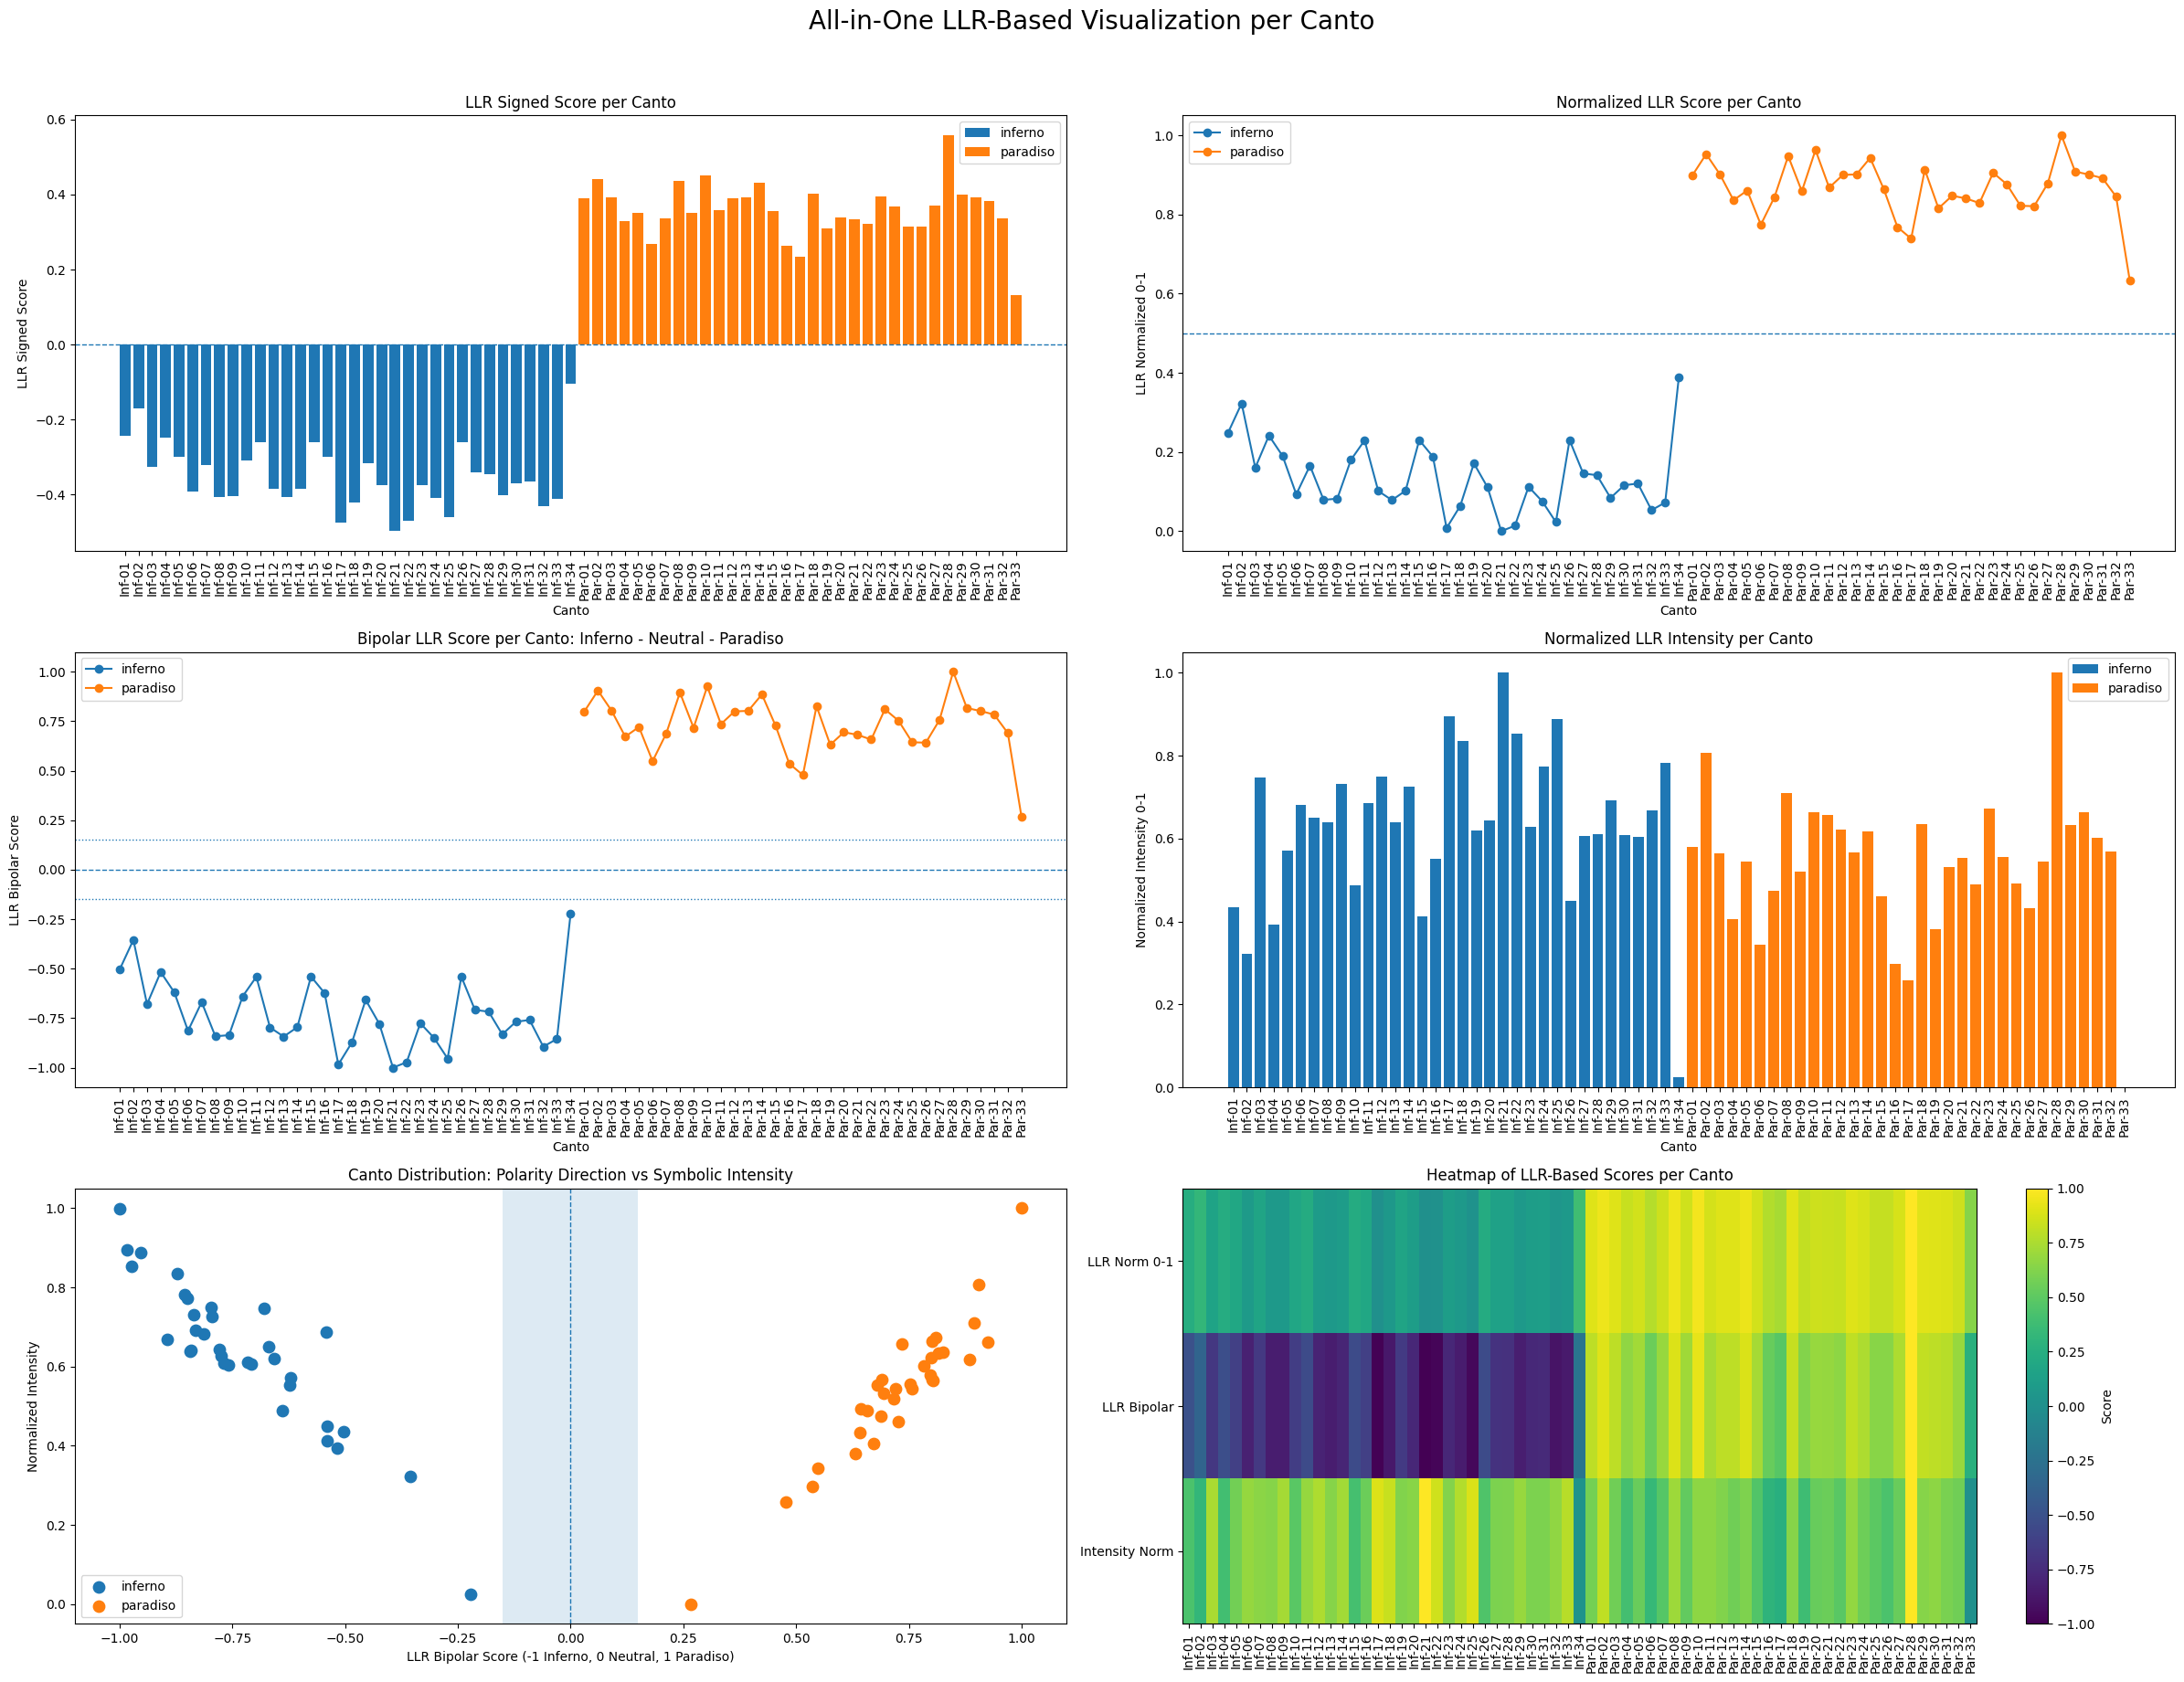

Visualisasi gabungan berhasil dibuat dan disimpan di:
/content/drive/MyDrive/_Dante_/data_processed/figures/00_all_llr_visualizations_per_canto.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

viz_df = manifest_df.copy()
viz_df = viz_df.sort_values(["cantica", "canto"]).reset_index(drop=True)

viz_df["canto_label"] = (
    viz_df["cantica"].str[:3] + "-" +
    viz_df["canto"].astype(str).str.zfill(2)
)
viz_df["x"] = np.arange(len(viz_df))

# ============================================================
# COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(24, 18)
)

axes = axes.flatten()

# LLR SIGNED PER CANTO
ax = axes[0]
for label, group in viz_df.groupby("label"):
    ax.bar(group["x"], group["llr_signed"], label=label)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(viz_df["x"])
ax.set_xticklabels(viz_df["canto_label"], rotation=90)
ax.set_xlabel("Canto")
ax.set_ylabel("LLR Signed Score")
ax.set_title("LLR Signed Score per Canto")
ax.legend()

# NORMALIZED LLR 0-1
ax = axes[1]
for label, group in viz_df.groupby("label"):
    ax.plot(group["x"], group["llr_norm_0_1"], marker="o", label=label)
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_xticks(viz_df["x"])
ax.set_xticklabels(viz_df["canto_label"], rotation=90)
ax.set_xlabel("Canto")
ax.set_ylabel("LLR Normalized 0-1")
ax.set_title("Normalized LLR Score per Canto")
ax.legend()

# BIPOLAR LLR -1 SAMPAI 1
ax = axes[2]
for label, group in viz_df.groupby("label"):
    ax.plot(group["x"], group["llr_bipolar"], marker="o", label=label)
ax.axhline(0, linestyle="--", linewidth=1)
ax.axhline(-0.15, linestyle=":", linewidth=1)
ax.axhline(0.15, linestyle=":", linewidth=1)
ax.set_xticks(viz_df["x"])
ax.set_xticklabels(viz_df["canto_label"], rotation=90)
ax.set_xlabel("Canto")
ax.set_ylabel("LLR Bipolar Score")
ax.set_title("Bipolar LLR Score per Canto: Inferno - Neutral - Paradiso")
ax.legend()

# INTENSITY SCORE PER CANTO
ax = axes[3]
for label, group in viz_df.groupby("label"):
    ax.bar(group["x"], group["intensity_norm_0_1"], label=label)
ax.set_xticks(viz_df["x"])
ax.set_xticklabels(viz_df["canto_label"], rotation=90)
ax.set_xlabel("Canto")
ax.set_ylabel("Normalized Intensity 0-1")
ax.set_title("Normalized LLR Intensity per Canto")
ax.legend()

# SCATTER: DIRECT VS INTENCITY
ax = axes[4]
for label, group in viz_df.groupby("label"):
    ax.scatter(
        group["llr_bipolar"],
        group["intensity_norm_0_1"],
        s=80,
        label=label
    )
ax.axvline(0, linestyle="--", linewidth=1)
ax.axvspan(-0.15, 0.15, alpha=0.15)
ax.set_xlabel("LLR Bipolar Score (-1 Inferno, 0 Neutral, 1 Paradiso)")
ax.set_ylabel("Normalized Intensity")
ax.set_title("Canto Distribution: Polarity Direction vs Symbolic Intensity")
ax.legend()

# HEATMAP
ax = axes[5]
heat_df = viz_df[[
    "llr_norm_0_1",
    "llr_bipolar",
    "intensity_norm_0_1"
]].T
im = ax.imshow(heat_df, aspect="auto")
ax.set_yticks(np.arange(3))
ax.set_yticklabels([
    "LLR Norm 0-1",
    "LLR Bipolar",
    "Intensity Norm"
])
ax.set_xticks(viz_df["x"])
ax.set_xticklabels(viz_df["canto_label"], rotation=90)
ax.set_title("Heatmap of LLR-Based Scores per Canto")
fig.colorbar(im, ax=ax, label="Score")

# FINAL LAYOUT + SAVE
fig.suptitle(
    "All-in-One LLR-Based Visualization per Canto",
    fontsize=20,
    y=1.02
)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "00_all_llr_visualizations_per_canto.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Visualisasi gabungan berhasil dibuat dan disimpan di:")
print(FIG_DIR / "00_all_llr_visualizations_per_canto.png")

**FUZZY MEMPERSHIP TRAPEZOIDAL INFERNO-PARADISO (67 CANTO) + VISUALIZATION**

,fuzzy_slot_67,cantica,canto,label,llr_norm_0_1,trapmf
0,1,Inferno,21,inferno,0.000000,"[0.0, 0.0022388059701492534, 0.012686567164179..."
1,2,Inferno,17,inferno,0.007803,"[0.014925373134328358, 0.017164179104477612, 0..."
2,3,Inferno,22,inferno,0.013631,"[0.029850746268656716, 0.03208955223880597, 0...."
3,4,Inferno,25,inferno,0.022924,"[0.04477611940298507, 0.04701492537313433, 0.0..."
4,5,Inferno,32,inferno,0.053021,"[0.05970149253731343, 0.06194029850746269, 0.0..."
...,...,...,...,...,...,...
62,63,Paradiso,14,paradiso,0.942678,"[0.9253731343283582, 0.9276119402985075, 0.938..."
63,64,Paradiso,8,paradiso,0.947309,"[0.9402985074626865, 0.9425373134328358, 0.952..."
64,65,Paradiso,2,paradiso,0.952332,"[0.9552238805970149, 0.9574626865671642, 0.967..."
65,66,Paradiso,10,paradiso,0.962650,"[0.9701492537313433, 0.9723880597014926, 0.982..."


Saved: /content/drive/MyDrive/_Dante_/data_processed/fuzzy_67_slots.csv


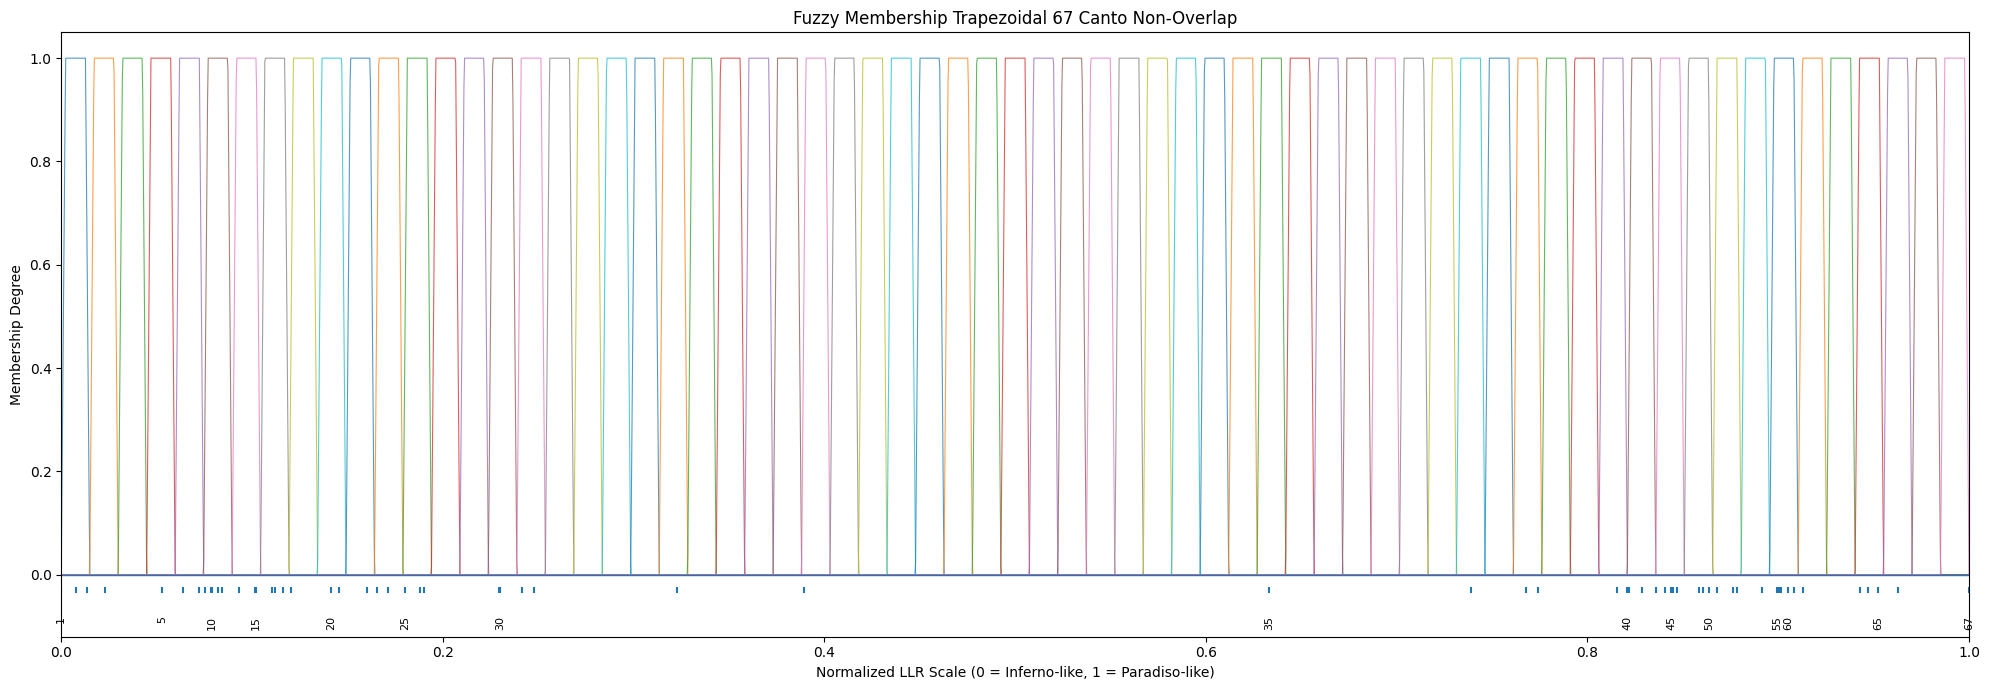

Saved: /content/drive/MyDrive/_Dante_/data_processed/figures/fuzzy_membership_67_trapezoid_one_plot.png


In [ ]:
import skfuzzy as fuzz
def build_67_nonoverlap_trapezoids(n_slots=67, eps_ratio=0.15):
    w = 1.0 / n_slots
    eps = eps_ratio * w
    traps = {}
    for k in range(n_slots):
        a = k * w
        d = (k + 1) * w
        b = a + eps
        c = d - eps
        traps[k + 1] = [a, b, c, d]
    return traps
traps_67 = build_67_nonoverlap_trapezoids(67)

# Mapping canto berdasarkan ranking LLR norm
ranked = manifest_df.sort_values("llr_norm_0_1").reset_index(drop=True)
ranked["fuzzy_slot_67"] = np.arange(1, 68)
ranked["trapmf"] = ranked["fuzzy_slot_67"].apply(lambda k: traps_67[k])
slot_path = OUT_DIR / "fuzzy_67_slots.csv"
ranked.to_csv(slot_path, index=False)
display(ranked[[
    "fuzzy_slot_67", "cantica", "canto", "label",
    "llr_norm_0_1", "trapmf"
]])

print("Saved:", slot_path)

# Visualization
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

x = np.linspace(0, 1, 3000)

plt.figure(figsize=(20, 7))

for slot, abcd in traps_67.items():
    y = fuzz.trapmf(x, abcd)
    plt.plot(x, y, linewidth=0.8, alpha=0.75)

# titik posisi canto berdasarkan ranking LLR
plt.scatter(
    ranked["llr_norm_0_1"],
    np.zeros(len(ranked)) - 0.03,
    s=18,
    marker="|",
    label="Canto position"
)

# label tiap beberapa slot biar tidak terlalu penuh
for _, row in ranked.iterrows():
    slot = row["fuzzy_slot_67"]
    if slot % 5 == 0 or slot in [1, 67]:
        plt.text(
            row["llr_norm_0_1"],
            -0.08,
            f"{slot}",
            ha="center",
            va="top",
            fontsize=8,
            rotation=90
        )

plt.axhline(0, linewidth=1)
plt.ylim(-0.12, 1.05)
plt.xlim(0, 1)

plt.xlabel("Normalized LLR Scale (0 = Inferno-like, 1 = Paradiso-like)")
plt.ylabel("Membership Degree")
plt.title("Fuzzy Membership Trapezoidal 67 Canto Non-Overlap")

plt.tight_layout()
plt.savefig(FIG_DIR / "fuzzy_membership_67_trapezoid_one_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIG_DIR / "fuzzy_membership_67_trapezoid_one_plot.png")

In [ ]:
# ============================================================
# 8. COARSE FUZZY: INFERNO / NEUTRAL / PARADISO
# Purgatorio nanti dianggap neutral saat testing
# ============================================================

def trapmf_value(x, abcd):
    a, b, c, d = abcd

    if x <= a or x >= d:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a) if b != a else 1.0
    elif b <= x <= c:
        return 1.0
    elif c < x < d:
        return (d - x) / (d - c) if d != c else 1.0
    else:
        return 0.0

# domain bipolar -1 sampai 1
MF_INFERNO = [-1.00, -1.00, -0.45, -0.10]
MF_NEUTRAL = [-0.15, -0.05,  0.05,  0.15]
MF_PARADISO = [0.10,  0.45,  1.00,  1.00]

def fuzzy_coarse_predict(bipolar_score):
    mu_inf = trapmf_value(bipolar_score, MF_INFERNO)
    mu_neu = trapmf_value(bipolar_score, MF_NEUTRAL)
    mu_par = trapmf_value(bipolar_score, MF_PARADISO)

    scores = {
        "inferno": mu_inf,
        "purgatorio": mu_neu,
        "paradiso": mu_par,
    }

    pred = max(scores, key=scores.get)
    return pred, mu_inf, mu_neu, mu_par

fuzzy_results = manifest_df["llr_bipolar"].apply(fuzzy_coarse_predict)

manifest_df["fuzzy_pred"] = fuzzy_results.apply(lambda x: x[0])
manifest_df["mu_inferno"] = fuzzy_results.apply(lambda x: x[1])
manifest_df["mu_purgatorio"] = fuzzy_results.apply(lambda x: x[2])
manifest_df["mu_paradiso"] = fuzzy_results.apply(lambda x: x[3])

display(manifest_df[[
    "cantica", "canto", "label",
    "llr_bipolar", "fuzzy_pred",
    "mu_inferno", "mu_purgatorio", "mu_paradiso"
]])

,cantica,canto,label,llr_bipolar,fuzzy_pred,mu_inferno,mu_purgatorio,mu_paradiso
0,Inferno,1,inferno,-0.504018,inferno,1.00000,0.0,0.000000
1,Inferno,2,inferno,-0.354684,inferno,0.72767,0.0,0.000000
2,Inferno,3,inferno,-0.679507,inferno,1.00000,0.0,0.000000
3,Inferno,4,inferno,-0.517269,inferno,1.00000,0.0,0.000000
4,Inferno,5,inferno,-0.620251,inferno,1.00000,0.0,0.000000
...,...,...,...,...,...,...,...,...
62,Paradiso,29,paradiso,0.816421,paradiso,0.00000,0.0,1.000000
63,Paradiso,30,paradiso,0.801405,paradiso,0.00000,0.0,1.000000
64,Paradiso,31,paradiso,0.783337,paradiso,0.00000,0.0,1.000000
65,Paradiso,32,paradiso,0.689807,paradiso,0.00000,0.0,1.000000


In [ ]:
# ============================================================
# 9. NAIVE BAYES TRAINING: INFERNO VS PARADISO
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

X = manifest_df["text"].values
y = manifest_df["label"].values

nb_model = Pipeline([
    ("vectorizer", CountVectorizer(
        lowercase=True,
        token_pattern=r"[a-zA-Z']+",
        stop_words=list(STOPWORDS),
        min_df=1
    )),
    ("nb", MultinomialNB(alpha=1.0))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(nb_model, X, y, cv=cv)

print("=== BINARY CV: INFERNO VS PARADISO ===")
print("Accuracy:", accuracy_score(y, y_pred_cv))
print("Balanced accuracy:", balanced_accuracy_score(y, y_pred_cv))
print(confusion_matrix(y, y_pred_cv))
print(classification_report(y, y_pred_cv))

nb_model.fit(X, y)

=== BINARY CV: INFERNO VS PARADISO ===
Accuracy: 0.9701492537313433
Balanced accuracy: 0.9705882352941176
[[32  2]
 [ 0 33]]
              precision    recall  f1-score   support

     inferno       1.00      0.94      0.97        34
    paradiso       0.94      1.00      0.97        33

    accuracy                           0.97        67
   macro avg       0.97      0.97      0.97        67
weighted avg       0.97      0.97      0.97        67



Pipeline(steps=[('vectorizer',
                 CountVectorizer(stop_words=['at', 'all', 'had', 'was', 'his',
                                             'is', 'the', 'on', 'or', 'with',
                                             'then', 'to', 'by', 'done',
                                             'could', 'she', 'them', 'whom',
                                             'where', 'are', 'he', 'would', 'a',
                                             'for', 'and', 'their', 'it', 'but',
                                             'there', 'should', ...],
                                 token_pattern="[a-zA-Z']+")),
                ('nb', MultinomialNB())])

<Figure size 700x600 with 0 Axes>

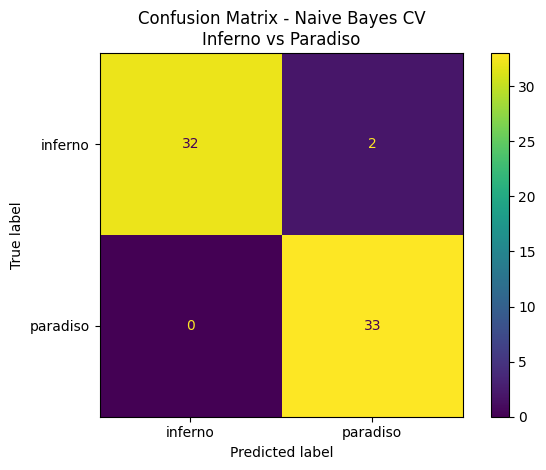

<Figure size 700x600 with 0 Axes>

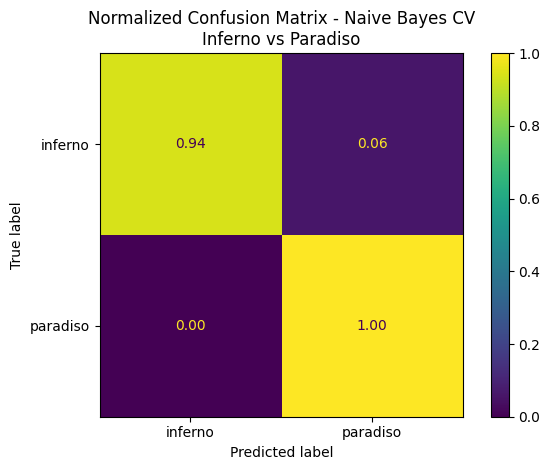

In [ ]:
# ============================================================
# VISUALISASI CONFUSION MATRIX — NAIVE BAYES INFERNO VS PARADISO
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["inferno", "paradiso"]

cm = confusion_matrix(y, y_pred_cv, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Confusion Matrix - Naive Bayes CV\nInferno vs Paradiso")
plt.tight_layout()

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIG_DIR / "confusion_matrix_naive_bayes_inferno_paradiso.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# CONFUSION MATRIX NORMALIZED / PERSENTASE
# ============================================================

cm_norm = confusion_matrix(
    y,
    y_pred_cv,
    labels=labels,
    normalize="true"
)

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=labels
)

plt.figure(figsize=(7, 6))
disp_norm.plot(values_format=".2f")
plt.title("Normalized Confusion Matrix - Naive Bayes CV\nInferno vs Paradiso")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "confusion_matrix_naive_bayes_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# SNS TESTING OUTPUT: INPUT → TRANSLATE → LLR → FUZZY → VISUAL
# ============================================================

!pip install -q deep-translator

from deep_translator import GoogleTranslator
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
import skfuzzy.control as ctrl
import re

# ============================================================
# 0. SAFETY CHECK
# ============================================================

required_vars = ["llr", "min_s", "max_s", "low", "high"]

for v in required_vars:
    if v not in globals():
        raise NameError(
            f"Variabel `{v}` belum ada. Jalankan dulu bagian LLR training dan normalisasi."
        )

llr_dict = llr

# ============================================================
# 1. BASIC FUNCTIONS
# ============================================================

def simple_tokenize(text):
    text = text.lower()
    tokens = re.findall(r"[a-z']+", text)
    tokens = [t.strip("'") for t in tokens]
    tokens = [t for t in tokens if len(t) > 2]
    return tokens


def score_text(text, llr_dict):
    words = simple_tokenize(text)
    scored_words = []

    for w in words:
        s = llr_dict.get(w, 0.0)
        scored_words.append((w, s))

    if len(scored_words) == 0:
        return 0.0, []

    score = float(np.mean([s for _, s in scored_words]))
    return score, scored_words


def normalize_score(score):
    score_clip = min(max(score, low), high)
    norm_0_1 = (score_clip - min_s) / (max_s - min_s)
    bipolar = 2 * norm_0_1 - 1
    return float(np.clip(bipolar, -1, 1))


def classify(score):

    # ========================================================
    # NORMALIZATION
    # ========================================================

    norm_score = normalize_score(score)

    input_intensity = min(abs(norm_score), 1.0)

    # ========================================================
    # DEBUG MEMBERSHIP
    # ========================================================

    print("\n=== FUZZY MEMBERSHIP DEBUG ===")

    print("Norm Score:", norm_score)

    print("Input Intensity:", input_intensity)

    print(
        "Negative membership:",
        fuzz.interp_membership(
            polarity.universe,
            polarity["negative"].mf,
            norm_score
        )
    )

    print(
        "Neutral membership:",
        fuzz.interp_membership(
            polarity.universe,
            polarity["neutral"].mf,
            norm_score
        )
    )

    print(
        "Positive membership:",
        fuzz.interp_membership(
            polarity.universe,
            polarity["positive"].mf,
            norm_score
        )
    )

    print(
        "Low intensity membership:",
        fuzz.interp_membership(
            intensity.universe,
            intensity["low"].mf,
            input_intensity
        )
    )

    print(
        "Medium intensity membership:",
        fuzz.interp_membership(
            intensity.universe,
            intensity["medium"].mf,
            input_intensity
        )
    )

    print(
        "High intensity membership:",
        fuzz.interp_membership(
            intensity.universe,
            intensity["high"].mf,
            input_intensity
        )
    )

    # ========================================================
    # REALM CLASSIFICATION
    # ========================================================

    if norm_score < -0.15:

        return "Inferno"

    elif norm_score <= 0.15:

        return "Purgatorio"

    else:

        return "Paradiso"


def annotate_words(words):
    annotated = []

    for w, s in words:
        if s < -0.05:
            label = "Inferno-like"
        elif s > 0.05:
            label = "Paradiso-like"
        else:
            label = "Neutral"

        annotated.append((w, s, label))

    annotated = sorted(annotated, key=lambda x: abs(x[1]), reverse=True)
    return annotated


# ============================================================
# 2. EXPLANATION FUNCTIONS
# ============================================================

def word_direction_label(word, score):
    fatigue_words = {
        "tired", "exhausted", "drained", "weary", "fatigue",
        "sleepy", "weak", "burnout", "overwhelmed"
    }

    despair_words = {
        "sad", "cry", "pain", "hurt", "lost", "alone",
        "broken", "dark", "fear", "afraid", "hopeless",
        "desperate", "suffer", "suffering"
    }

    recovery_words = {
        "try", "trying", "hope", "heal", "recover", "breathe",
        "rest", "continue", "again", "better", "rise"
    }

    light_words = {
        "happy", "peace", "love", "bright", "light", "grateful",
        "calm", "joy", "blessed", "smile", "safe"
    }

    w = word.lower()

    if score < -0.05:
        if w in fatigue_words:
            return "Inferno - fatigue"
        elif w in despair_words:
            return "Inferno - despair"
        else:
            return "Inferno - surface"

    elif score > 0.05:
        if w in recovery_words:
            return "Paradiso - recovery"
        elif w in light_words:
            return "Paradiso - harmony"
        else:
            return "Paradiso - general"

    else:
        return "Purgatorio - neutral"


def get_emotion_summary(norm_score, fuzzy_label):
    if fuzzy_label == "Inferno":
        if norm_score < -0.65:
            return (
                "emosi cenderung berada pada area tekanan kuat, seperti "
                "kelelahan, kehilangan arah, atau beban psikologis yang dominan."
            )
        else:
            return (
                "emosi cenderung negatif, tetapi belum sepenuhnya ekstrem; "
                "terdapat tekanan emosional yang masih dapat bergeser."
            )

    elif fuzzy_label == "Purgatorio":
        return (
            "emosi berada di area ambigu (liminal), menunjukkan campuran antara "
            "kelelahan, refleksi, dan sedikit dorongan untuk pulih."
        )

    else:
        if norm_score > 0.65:
            return (
                "emosi cenderung positif dan stabil, menunjukkan penerimaan, "
                "ketenangan, atau dorongan menuju pemulihan."
            )
        else:
            return (
                "emosi cenderung positif ringan, dengan tanda adanya harapan, "
                "regulasi diri, atau pergerakan menuju kondisi yang lebih tenang."
            )


def explain_result(text, score, final_label, fuzzy_label, annotated):
    top_words = annotated[:5]
    norm_score = normalize_score(score)

    lines = []

    lines.append(
        f"Kalimat ini dianalisis memiliki skor emosional {score:.2f}, "
        f"yang mengarah ke kategori {final_label} dengan interpretasi fuzzy sebagai {fuzzy_label}."
    )

    lines.append(
        f"Secara umum, {get_emotion_summary(norm_score, fuzzy_label)}"
    )

    lines.append("Kontribusi kata yang paling berpengaruh adalah:")

    if len(top_words) == 0:
        lines.append("- Tidak ada kata yang cocok dengan kamus LLR.")
    else:
        for w, s, _ in top_words:
            interp = word_direction_label(w, s)
            lines.append(
                f"- '{w}' dengan skor {s:.2f} yang mengarah ke {interp}"
            )

    if fuzzy_label == "Purgatorio":
        lines.append(
            "Keseluruhan struktur bahasa berada dalam transisi, tidak sepenuhnya negatif maupun positif."
        )
    elif fuzzy_label == "Inferno":
        lines.append(
            "Keseluruhan struktur bahasa lebih condong pada tekanan emosional, distress, atau penurunan kondisi afektif."
        )
    else:
        lines.append(
            "Keseluruhan struktur bahasa lebih condong pada pemulihan, penerimaan, atau stabilitas emosional positif."
        )

    return "\n".join(lines)


# ============================================================
# 3. FUZZY SYSTEM + DANTE SUB-LAYER MAPPING
# ============================================================

polarity = ctrl.Antecedent(
    np.arange(-1, 1.01, 0.01),
    "polarity"
)

intensity = ctrl.Antecedent(
    np.arange(0, 1.01, 0.01),
    "intensity"
)

realm = ctrl.Consequent(
    np.arange(0, 2.01, 0.01),
    "realm"
)

# ============================================================
# POLARITY MEMBERSHIP
# ============================================================

polarity["negative"] = fuzz.trapmf(
    polarity.universe,
    [-1, -1, -0.45, -0.10]
)

polarity["neutral"] = fuzz.trimf(
    polarity.universe,
    [-0.20, 0, 0.20]
)

polarity["positive"] = fuzz.trapmf(
    polarity.universe,
    [0.10, 0.45, 1, 1]
)

# ============================================================
# INTENSITY MEMBERSHIP
# ============================================================

intensity["low"] = fuzz.trapmf(
    intensity.universe,
    [0, 0, 0.25, 0.45]
)

intensity["medium"] = fuzz.trimf(
    intensity.universe,
    [0.25, 0.50, 0.75]
)

intensity["high"] = fuzz.trapmf(
    intensity.universe,
    [0.55, 0.75, 1, 1]
)

# ============================================================
# REALM MEMBERSHIP
# ============================================================

realm["inferno"] = fuzz.trapmf(
    realm.universe,
    [0, 0, 0.45, 0.85]
)

realm["purgatorio"] = fuzz.trimf(
    realm.universe,
    [0.65, 1.0, 1.35]
)

realm["paradiso"] = fuzz.trapmf(
    realm.universe,
    [1.15, 1.55, 2, 2]
)

# ============================================================
# FUZZY RULES
# ============================================================

rule1 = ctrl.Rule(
    polarity["negative"] & intensity["high"],
    realm["inferno"]
)

rule2 = ctrl.Rule(
    polarity["negative"] & intensity["medium"],
    realm["inferno"]
)

rule3 = ctrl.Rule(
    polarity["neutral"],
    realm["purgatorio"]
)

rule4 = ctrl.Rule(
    polarity["positive"] & intensity["medium"],
    realm["paradiso"]
)

rule5 = ctrl.Rule(
    polarity["positive"] & intensity["high"],
    realm["paradiso"]
)

rule6 = ctrl.Rule(
    polarity["negative"] & intensity["low"],
    realm["inferno"]
)

rule7 = ctrl.Rule(
    polarity["positive"] & intensity["low"],
    realm["paradiso"]
)

realm_ctrl = ctrl.ControlSystem([
    rule1,
    rule2,
    rule3,
    rule4,
    rule5,
    rule6,
    rule7
])

# ============================================================
# REALM INTERPRETATION
# ============================================================

def interpret_realm(value):

    if value < 0.75:
        return "Inferno"

    elif value < 1.5:
        return "Purgatorio"

    else:
        return "Paradiso"

# ============================================================
# DANTE SUB-LAYER HIERARCHY
# ============================================================

inferno_circles = [

    "Circle 1 - Limbo",
    "Circle 2 - Lust",
    "Circle 3 - Gluttony",
    "Circle 4 - Greed",
    "Circle 5 - Wrath",
    "Circle 6 - Heresy",
    "Circle 7 - Violence",
    "Circle 8 - Fraud",
    "Circle 9 - Treachery"
]

purgatorio_terraces = [

    "Ante-Purgatory",
    "Terrace 1 - Pride",
    "Terrace 2 - Envy",
    "Terrace 3 - Wrath",
    "Terrace 4 - Sloth",
    "Terrace 5 - Greed",
    "Terrace 6 - Gluttony",
    "Terrace 7 - Lust",
    "Earthly Paradise"
]

paradiso_spheres = [

    "Sphere 1 - Moon",
    "Sphere 2 - Mercury",
    "Sphere 3 - Venus",
    "Sphere 4 - Sun",
    "Sphere 5 - Mars",
    "Sphere 6 - Jupiter",
    "Sphere 7 - Saturn",
    "Sphere 8 - Fixed Stars",
    "Sphere 9 - Primum Mobile",
    "Sphere 10 - Empyrean"
]

# ============================================================
# SUB-LAYER MAPPING
# ============================================================

def map_dante_sublayer(norm_score, fuzzy_label):

    label = fuzzy_label.lower()

    # ========================================================
    # INFERNO
    # ========================================================

    if label == "inferno":

        depth = min(abs(norm_score), 1.0)

        idx = int(
            depth * (len(inferno_circles) - 1)
        )

        idx = np.clip(
            idx,
            0,
            len(inferno_circles) - 1
        )

        return inferno_circles[idx]

    # ========================================================
    # PURGATORIO
    # ========================================================

    elif label == "purgatorio":

        scaled = (
            norm_score + 0.15
        ) / 0.30

        scaled = np.clip(
            scaled,
            0,
            1
        )

        idx = int(
            scaled * (len(purgatorio_terraces) - 1)
        )

        idx = np.clip(
            idx,
            0,
            len(purgatorio_terraces) - 1
        )

        return purgatorio_terraces[idx]

    # ========================================================
    # PARADISO
    # ========================================================

    elif label == "paradiso":

        height = min(abs(norm_score), 1.0)

        idx = int(
            height * (len(paradiso_spheres) - 1)
        )

        idx = np.clip(
            idx,
            0,
            len(paradiso_spheres) - 1
        )

        return paradiso_spheres[idx]

    # ========================================================
    # UNKNOWN
    # ========================================================

    else:
        return "Unknown"

# ============================================================
# DANTE SYMBOLIC EXPLANATION
# ============================================================

DANTE_LAYER_EXPLANATION = {

    # ========================================================
    # INFERNO
    # ========================================================

    "Circle 1 - Limbo":
        "menggambarkan kekosongan, keterasingan, atau mati rasa emosional.",

    "Circle 2 - Lust":
        "menggambarkan dorongan emosional yang impulsif, obsesi, atau ketergantungan terhadap sesuatu.",

    "Circle 3 - Gluttony":
        "menggambarkan kondisi emosional yang berlebihan, kelelahan akibat konsumsi berlebih, atau rasa tidak pernah cukup secara emosional.",

    "Circle 4 - Greed":
        "menggambarkan kecemasan terhadap kehilangan, keterikatan berlebihan, atau kebutuhan untuk mempertahankan kontrol.",

    "Circle 5 - Wrath":
        "menggambarkan kemarahan, frustrasi, atau tekanan emosional yang mulai meluap.",

    "Circle 6 - Heresy":
        "menggambarkan penolakan, keterasingan batin, atau konflik terhadap makna dan keyakinan diri.",

    "Circle 7 - Violence":
        "menggambarkan tekanan emosional yang destruktif, baik terhadap diri sendiri maupun lingkungan sekitar.",

    "Circle 8 - Fraud":
        "menggambarkan konflik emosional yang berkaitan dengan manipulasi, kepalsuan, atau ketidakpercayaan.",

    "Circle 9 - Treachery":
        "menggambarkan kehancuran emosional mendalam, pengkhianatan, atau kehilangan koneksi emosional.",

    # ========================================================
    # PURGATORIO
    # ========================================================

    "Ante-Purgatory":
        "menggambarkan keadaan menggantung, belum sepenuhnya jatuh tetapi juga belum pulih.",

    "Terrace 1 - Pride":
        "menggambarkan refleksi diri dan kesadaran terhadap ego atau identitas diri.",

    "Terrace 2 - Envy":
        "menggambarkan perbandingan diri dan ketidakpuasan terhadap keadaan pribadi.",

    "Terrace 3 - Wrath":
        "menggambarkan proses regulasi emosi dan usaha menenangkan tekanan batin.",

    "Terrace 4 - Sloth":
        "menggambarkan stagnasi emosional, kelelahan motivasi, atau kehilangan dorongan bergerak.",

    "Terrace 5 - Greed":
        "menggambarkan usaha melepaskan keterikatan emosional atau kebutuhan berlebih.",

    "Terrace 6 - Gluttony":
        "menggambarkan proses pengendalian kebutuhan emosional dan pencarian keseimbangan.",

    "Terrace 7 - Lust":
        "menggambarkan proses pemurnian keinginan, relasi, dan dorongan emosional.",

    "Earthly Paradise":
        "menggambarkan keadaan pemulihan, kejernihan, dan kesiapan menuju stabilitas emosional.",

    # ========================================================
    # PARADISO
    # ========================================================

    "Sphere 1 - Moon":
        "menggambarkan emosi yang mulai stabil tetapi masih mudah berubah.",

    "Sphere 2 - Mercury":
        "menggambarkan dorongan untuk berkembang, bergerak maju, dan menemukan arah.",

    "Sphere 3 - Venus":
        "menggambarkan kasih sayang, koneksi emosional, dan afeksi.",

    "Sphere 4 - Sun":
        "menggambarkan kejernihan berpikir, pemahaman diri, dan kebijaksanaan emosional.",

    "Sphere 5 - Mars":
        "menggambarkan keberanian menghadapi tekanan dan ketahanan emosional.",

    "Sphere 6 - Jupiter":
        "menggambarkan keseimbangan, keadilan emosional, dan regulasi diri.",

    "Sphere 7 - Saturn":
        "menggambarkan refleksi mendalam, ketenangan, dan kontemplasi.",

    "Sphere 8 - Fixed Stars":
        "menggambarkan harapan, keyakinan, dan kestabilan emosional yang lebih tinggi.",

    "Sphere 9 - Primum Mobile":
        "menggambarkan keteraturan emosional dan harmoni batin.",

    "Sphere 10 - Empyrean":
        "menggambarkan keadaan kedamaian emosional tertinggi dan penerimaan penuh."
}


def explain_dante_layer(layer_name):

    return DANTE_LAYER_EXPLANATION.get(
        layer_name,
        "tidak ada penjelasan simbolik."
    )

# ============================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================

def plot_llr_contribution(annotated, top_n=10):
    data = annotated[:top_n]

    if len(data) == 0:
        print("Tidak ada kontribusi kata untuk divisualisasikan.")
        return

    words = [w for w, s, l in data]
    scores = [s for w, s, l in data]

    plt.figure(figsize=(12, 4))
    plt.bar(words, scores)
    plt.axhline(0, linestyle="--")
    plt.title("Top LLR Word Contributions")
    plt.xlabel("Words")
    plt.ylabel("LLR Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_fuzzy_system(norm_score, fuzzy_output):
    x = np.linspace(-1, 1, 300)

    negative = fuzz.trapmf(x, [-1, -1, -0.45, -0.10])
    neutral = fuzz.trimf(x, [-0.20, 0, 0.20])
    positive = fuzz.trapmf(x, [0.10, 0.45, 1, 1])

    plt.figure(figsize=(10, 5))
    plt.plot(x, negative, label="Inferno")
    plt.plot(x, neutral, label="Purgatorio")
    plt.plot(x, positive, label="Paradiso")
    plt.axvline(norm_score, linestyle="--", label="Input Score")
    plt.title("Fuzzy Membership - Input Polarity")
    plt.xlabel("Normalized Bipolar Score")
    plt.ylabel("Membership Degree")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y = np.linspace(0, 2, 300)

    inferno = fuzz.trapmf(y, [0, 0, 0.45, 0.85])
    purgatorio = fuzz.trimf(y, [0.65, 1.0, 1.35])
    paradiso = fuzz.trapmf(y, [1.15, 1.55, 2, 2])

    plt.figure(figsize=(10, 5))
    plt.plot(y, inferno, label="Inferno")
    plt.plot(y, purgatorio, label="Purgatorio")
    plt.plot(y, paradiso, label="Paradiso")
    plt.axvline(fuzzy_output, linestyle="--", label="Fuzzy Output")
    plt.title("Fuzzy Output Realm")
    plt.xlabel("Realm Output")
    plt.ylabel("Membership Degree")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# CONTEXTUAL OVERRIDE FOR AGGRESSION / HOSTILITY
# ============================================================

AGGRESSION_TERMS = {
    "bastard", "asshole", "fuck", "shit", "damn",
    "bajingan", "bangsat", "anjing", "kontol", "goblok",
    "mati", "die", "dead", "kill", "neraka", "hell",
    "hate", "hated", "hateful"
}

HOSTILE_PATTERNS = [
    r"\bdie\b",
    r"\bgo to hell\b",
    r"\bkill\b",
    r"\bmati\b",
    r"\bmasuk neraka\b",
    r"\bmending .* mati\b",
    r"\bbetter .* die\b",
]

def detect_hostile_context(original_text, translated_text):
    combined = f"{original_text.lower()} {translated_text.lower()}"

    term_hits = [
        term for term in AGGRESSION_TERMS
        if re.search(rf"\b{re.escape(term)}\b", combined)
    ]

    pattern_hits = [
        pat for pat in HOSTILE_PATTERNS
        if re.search(pat, combined)
    ]

    is_hostile = len(term_hits) >= 2 or len(pattern_hits) > 0

    return {
        "is_hostile": is_hostile,
        "term_hits": term_hits,
        "pattern_hits": pattern_hits
    }


def apply_contextual_override(
    original_text,
    translated_text,
    final_label,
    fuzzy_label,
    dante_sublayer
):
    hostile = detect_hostile_context(original_text, translated_text)

    if hostile["is_hostile"]:
        return {
            "final_label": "Inferno",
            "fuzzy_label": "Inferno",
            "dante_sublayer": "Circle 5 - Wrath",
            "override_reason": (
                "Terdeteksi konteks agresi/verbal hostility, seperti "
                f"{hostile['term_hits']} dan pola {hostile['pattern_hits']}. "
                "Karena itu hasil lexical LLR dikoreksi ke Inferno."
            ),
            "override_applied": True
        }

    return {
        "final_label": final_label,
        "fuzzy_label": fuzzy_label,
        "dante_sublayer": dante_sublayer,
        "override_reason": None,
        "override_applied": False
    }

In [ ]:
# ============================================================
# CONTEXTUAL EMOTIONAL CUES
# ============================================================

RECOVERY_CUES = {
    "recover", "healing", "heal", "survive",
    "improve", "better", "rise", "stronger",
    "hope", "slowly", "trying", "try",
    "move on", "continue", "keep going"
}

HOSTILITY_CUES = {
    "kill", "die", "dead", "hell",
    "hate", "destroy", "burn",
    "bastard", "damn", "bangsat",
    "bajingan", "anjing", "mati",
    "neraka"
}

UNCERTAINTY_CUES = {
    "maybe", "perhaps", "i guess",
    "entahlah", "mungkin", "kayaknya",
    "not sure", "unsure", "idk"
}

MASKING_CUES = {
    "i'm okay", "fine", "gapapa",
    "baik baik aja", "it's okay",
    "nothing", "never mind"
}

EXHAUSTION_CUES = {
    "tired", "exhausted", "burnout",
    "drained", "empty", "numb",
    "cape", "capek", "lelah"
}

# ============================================================
# CONTEXT DETECTION
# ============================================================

import re


def detect_contextual_cues(text):

    text = text.lower()

    detected = {
        "recovery": [],
        "hostility": [],
        "uncertainty": [],
        "masking": [],
        "exhaustion": []
    }

    for cue in RECOVERY_CUES:
        if cue in text:
            detected["recovery"].append(cue)

    for cue in HOSTILITY_CUES:
        if cue in text:
            detected["hostility"].append(cue)

    for cue in UNCERTAINTY_CUES:
        if cue in text:
            detected["uncertainty"].append(cue)

    for cue in MASKING_CUES:
        if cue in text:
            detected["masking"].append(cue)

    for cue in EXHAUSTION_CUES:
        if cue in text:
            detected["exhaustion"].append(cue)

    return detected

# ============================================================
# CONTEXTUAL EMOTIONAL ADJUSTMENT
# ============================================================


def contextual_adjustment(
    norm_score,
    fuzzy_label,
    dante_sublayer,
    text
):

    cues = detect_contextual_cues(text)

    recovery_hits = len(cues["recovery"])
    hostility_hits = len(cues["hostility"])
    uncertainty_hits = len(cues["uncertainty"])
    masking_hits = len(cues["masking"])
    exhaustion_hits = len(cues["exhaustion"])

    adjustment_note = [] # Re-introduced adjustment_note initialization

    # Store current values to modify and return
    current_fuzzy_label = fuzzy_label
    current_dante_sublayer = dante_sublayer

    # ========================================================
    # HOSTILITY OVERRIDE
    # ========================================================

    if hostility_hits >= 2:

        current_fuzzy_label = "Inferno"
        current_dante_sublayer = "Circle 5 - Wrath"
        adjustment_note.append("hostility/aggression cue detected") # Added note

    # ========================================================
    # RECOVERY TRAJECTORY
    # ========================================================

    elif exhaustion_hits >= 1 and recovery_hits >= 1:

        current_fuzzy_label = "Purgatorio"
        current_dante_sublayer = "Terrace 4 - Sloth"
        adjustment_note.append("recovery trajectory detected") # Added note

    # ========================================================
    # UNCERTAINTY / LIMINAL STATE
    # ========================================================

    elif uncertainty_hits >= 1:

        current_fuzzy_label = "Purgatorio"
        adjustment_note.append("uncertainty/liminal cue detected") # Added note

    # ========================================================

    return {
        "fuzzy_label": current_fuzzy_label,
        "dante_sublayer": current_dante_sublayer,
        "cues": cues,
        "adjustment_note": adjustment_note
    }


Masukkan teks: pemerintah bangsattt, makan tuh uang haram, timbun aja terus tuh dosa, semoga kalian tentram di neraka

Normalized: pemerintah bangsat makan tuh uang haram timbun saja terus tuh dosa semoga kalian tentram di neraka
Translated: The government is a bastard, eating haram money and hoarding it is a sin, hope you will be at peace in hell

=== FUZZY MEMBERSHIP DEBUG ===
Norm Score: -0.13411195631741624
Input Intensity: 0.13411195631741624
Negative membership: 0.09746273233547495
Neutral membership: 0.3294402184129189
Positive membership: 0.0
Low intensity membership: 1.0
Medium intensity membership: 0.0
High intensity membership: 0.0

=== SNS TEST ===
Original Text: pemerintah bangsattt, makan tuh uang haram, timbun aja terus tuh dosa, semoga kalian tentram di neraka
Normalized Text: pemerintah bangsat makan tuh uang haram timbun saja terus tuh dosa semoga kalian tentram di neraka
Translated Text: The government is a bastard, eating haram money and hoarding it is a sin, hope y

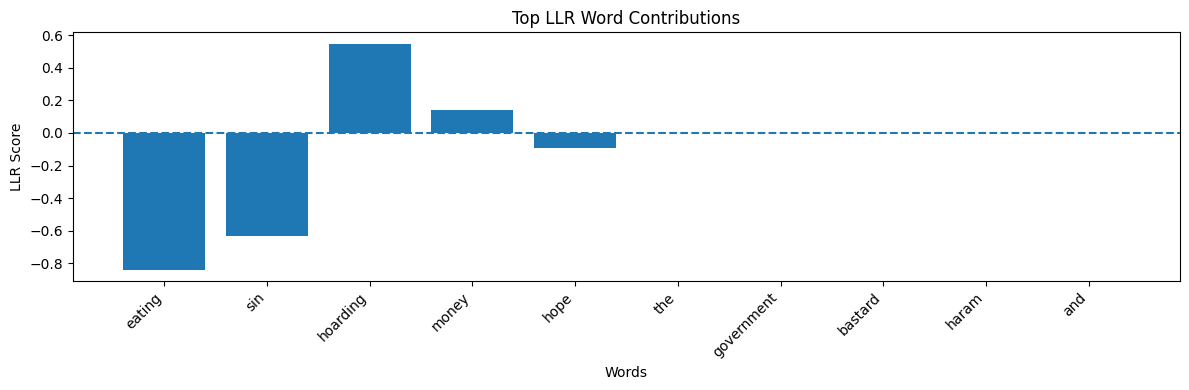

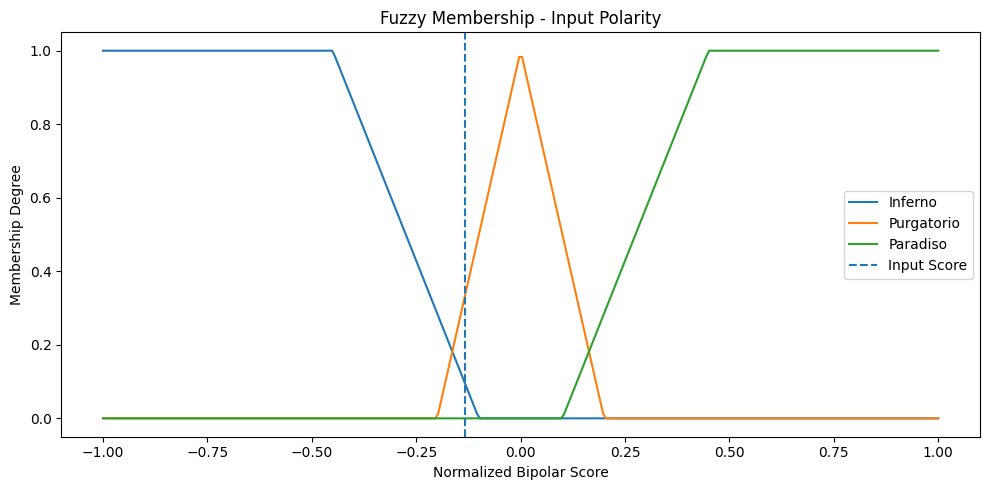

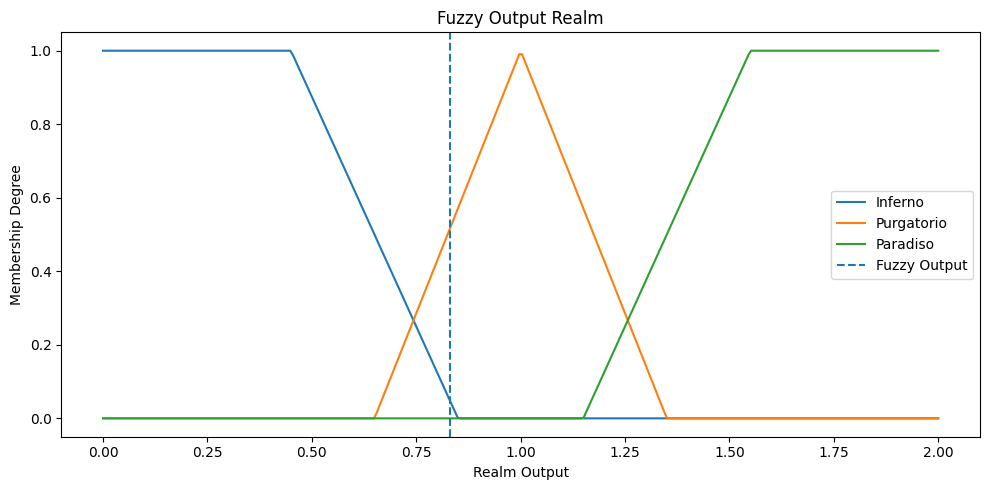

In [ ]:
# ============================================================
# 5. RUN TESTING + DANTE SUB-LAYER OUTPUT
# ============================================================

text_id = input("Masukkan teks: ")

# Optional: kalau kamu sudah punya normalize_sns_text()
if "normalize_sns_text" in globals():
    text_norm = normalize_sns_text(text_id)
else:
    text_norm = text_id

text_en = GoogleTranslator(
    source="auto",
    target="en"
).translate(text_norm)

print("\nNormalized:", text_norm)
print("Translated:", text_en)

# ============================================================
# 1. LLR SCORING
# ============================================================

score, words = score_text(text_en, llr_dict)
annotated = annotate_words(words)

final_label = classify(score)

# ============================================================
# 2. FUZZY SYSTEM
# ============================================================

norm_score = normalize_score(score)
input_intensity = min(abs(norm_score), 1.0)

realm_sim = ctrl.ControlSystemSimulation(realm_ctrl)

realm_sim.input["polarity"] = norm_score
realm_sim.input["intensity"] = input_intensity

realm_sim.compute()

fuzzy_output = realm_sim.output["realm"]
fuzzy_label = interpret_realm(fuzzy_output)

# ============================================================
# 3. DANTE SUB-LAYER
# ============================================================

dante_sublayer = map_dante_sublayer(
    norm_score,
    fuzzy_label
)

# ============================================================
# 4. CONTEXTUAL OVERRIDE
# ============================================================

override_result = apply_contextual_override(
    text_id,
    text_en,
    final_label,
    fuzzy_label,
    dante_sublayer
)

final_label = override_result["final_label"]
fuzzy_label = override_result["fuzzy_label"]
dante_sublayer = override_result["dante_sublayer"]

override_applied = override_result["override_applied"]
override_reason = override_result["override_reason"]

# ============================================================
# 5. CONTEXTUAL CUE ADJUSTMENT
# ============================================================

context_result = contextual_adjustment(
    norm_score,
    fuzzy_label,
    dante_sublayer,
    text_en
)

fuzzy_label = context_result["fuzzy_label"]

dante_sublayer = context_result["dante_sublayer"]

contextual_cues = context_result["cues"]

adjustment_note = context_result["adjustment_note"]

# ============================================================
# 4. OUTPUT
# ============================================================

raw_fuzzy_label = interpret_realm(fuzzy_output)

print("\n=== SNS TEST ===")

print("Original Text:", text_id)

print("Normalized Text:", text_norm)

print("Translated Text:", text_en)

print("Raw LLR Score:", score)

print("Normalized Bipolar Score:", norm_score)

print("Input Intensity:", input_intensity)

print("Threshold Label:", final_label)

print("Fuzzy Output:", fuzzy_output)

# ============================================================
# RAW VS FINAL FUZZY
# ============================================================

print("Raw Fuzzy Label:", raw_fuzzy_label)

print("Final Fuzzy Label:", fuzzy_label)

print("Dante Sub-layer:", dante_sublayer)

# ============================================================
# CONTEXT OVERRIDE
# ============================================================

print("Context Override Applied:", override_applied)

if override_applied:
    print("Override Reason:", override_reason)

# ============================================================
# CONTEXTUAL CUES
# ============================================================

print("\n=== CONTEXTUAL CUES ===")

has_cues = False

for k, v in contextual_cues.items():

    if len(v) > 0:

        has_cues = True

        print(f"{k}: {v}")

if not has_cues:

    print("No significant contextual cues detected.")

# ============================================================
# CONTEXTUAL ADJUSTMENT
# ============================================================

if len(adjustment_note) > 0:

    print("\n=== CONTEXTUAL ADJUSTMENT ===")

    for note in adjustment_note:

        print("-", note)

# ============================================================
# TOP WORD CONTRIBUTIONS
# ============================================================

print("\n=== TOP WORD CONTRIBUTIONS ===")

for w, s, label in annotated[:10]:

    print(f"{w:15} {s: .4f} → {label}")

# ============================================================
# 5. EXPLANATION
# ============================================================

explanation = explain_result(
    text_en,
    score,
    final_label,
    fuzzy_label,
    annotated
)

print("\n=== EXPLANATION ===")
print(explanation)

print("\n=== DANTE HIERARCHICAL INTERPRETATION ===")

print(
    f"Teks ini berada pada realm {fuzzy_label} "
    f"dengan lapisan simbolik: {dante_sublayer}."
)

print(
    "Interpretasi simbolik:"
)

print(
    explain_dante_layer(dante_sublayer)
)

# ============================================================
# 6. VISUALIZATION
# ============================================================

plot_llr_contribution(annotated, top_n=10)
plot_fuzzy_system(norm_score, fuzzy_output)

In [ ]:
# ============================================================
# LLR CONSISTENCY CHECK
# Mengecek apakah kata dengan skor LLR tinggi
# benar-benar konsisten muncul pada corpus yang sesuai
# ============================================================

def get_top_llr(llr_dict, threshold=1.0):
    """
    Ambil kata dengan magnitude LLR tinggi.
    """

    return {
        w: v
        for w, v in llr_dict.items()
        if abs(v) > threshold
    }


def check_llr_consistency(top_llr, inferno_text, paradiso_text):
    """
    Mengukur konsistensi arah LLR terhadap corpus asli.
    """

    inferno_hits = 0
    paradiso_hits = 0

    inferno_total = 0
    paradiso_total = 0

    details = []

    for word, score in top_llr.items():

        in_inferno = word in inferno_text
        in_paradiso = word in paradiso_text

        # ====================================================
        # Inferno-oriented words
        # ====================================================
        if score < 0:
            inferno_total += 1

            if in_inferno:
                inferno_hits += 1
                consistent = True
            else:
                consistent = False

            details.append({
                "word": word,
                "score": score,
                "expected": "Inferno",
                "inferno_found": in_inferno,
                "paradiso_found": in_paradiso,
                "consistent": consistent
            })

        # ====================================================
        # Paradiso-oriented words
        # ====================================================
        elif score > 0:
            paradiso_total += 1

            if in_paradiso:
                paradiso_hits += 1
                consistent = True
            else:
                consistent = False

            details.append({
                "word": word,
                "score": score,
                "expected": "Paradiso",
                "inferno_found": in_inferno,
                "paradiso_found": in_paradiso,
                "consistent": consistent
            })

    total_words = inferno_total + paradiso_total

    consistency_score = (
        (inferno_hits + paradiso_hits) / total_words
        if total_words > 0 else 0
    )

    return {
        "consistency_score": consistency_score,
        "inferno_hits": inferno_hits,
        "inferno_total": inferno_total,
        "paradiso_hits": paradiso_hits,
        "paradiso_total": paradiso_total,
        "details": details
    }


# ============================================================
# GABUNGKAN FULL CORPUS
# ============================================================

inferno_text = " ".join(
    manifest_df[
        manifest_df["label"] == "inferno"
    ]["text"].tolist()
).lower()

paradiso_text = " ".join(
    manifest_df[
        manifest_df["label"] == "paradiso"
    ]["text"].tolist()
).lower()


# ============================================================
# AMBIL KATA DENGAN LLR TINGGI
# ============================================================

top_llr = get_top_llr(
    llr_dict,
    threshold=1.0
)


# ============================================================
# CEK KONSISTENSI
# ============================================================

result = check_llr_consistency(
    top_llr,
    inferno_text,
    paradiso_text
)

llr_consistency = result["consistency_score"]


# ============================================================
# OUTPUT
# ============================================================

print("================================================")
print("LLR CONSISTENCY CHECK")
print("================================================")

print(f"Total High-LLR Words : {len(top_llr)}")
print()

print(
    f"Inferno Consistency : "
    f"{result['inferno_hits']} / {result['inferno_total']}"
)

print(
    f"Paradiso Consistency: "
    f"{result['paradiso_hits']} / {result['paradiso_total']}"
)

print()
print(f"LLR Consistency Score: {llr_consistency:.4f}")

# ============================================================
# INTERPRETASI
# ============================================================

if llr_consistency >= 0.90:
    print("Interpretation: VERY STRONG symbolic consistency.")
elif llr_consistency >= 0.75:
    print("Interpretation: STRONG symbolic consistency.")
elif llr_consistency >= 0.60:
    print("Interpretation: MODERATE symbolic consistency.")
else:
    print("Interpretation: WEAK symbolic consistency.")

# ============================================================
# TOP CONSISTENT WORDS
# ============================================================

detail_df = pd.DataFrame(result["details"])

consistent_df = detail_df[
    detail_df["consistent"] == True
].sort_values(
    by="score",
    key=lambda s: abs(s),
    ascending=False
)

print("\n================================================")
print("TOP CONSISTENT LLR WORDS")
print("================================================")

display(
    consistent_df.head(20)
)

LLR CONSISTENCY CHECK
Total High-LLR Words : 1716

Inferno Consistency : 1008 / 1055
Paradiso Consistency: 645 / 661

LLR Consistency Score: 0.9633
Interpretation: VERY STRONG symbolic consistency.

TOP CONSISTENT LLR WORDS


,word,score,expected,inferno_found,paradiso_found,consistent
112,bank,-3.364617,Inferno,True,True,True
330,crag,-3.190263,Inferno,True,False,True
946,moat,-2.978954,Inferno,True,False,True
467,effulgence,2.849991,Paradiso,False,True,True
1486,tail,-2.784798,Inferno,True,True,True
168,bolgia,-2.784798,Inferno,True,False,True
1535,thrones,2.744631,Paradiso,False,True,True
716,horrible,-2.710690,Inferno,True,False,True
1198,reflected,2.687472,Paradiso,False,True,True
1129,properties,2.687472,Paradiso,False,True,True


In [ ]:
# ============================================================
# BETTER LLR CONSISTENCY CHECK
# Berdasarkan frekuensi, bukan sekadar kemunculan kata
# ============================================================

from collections import Counter
import pandas as pd
import numpy as np

inferno_tokens = tokenize(inferno_text)
paradiso_tokens = tokenize(paradiso_text)

freq_inf = Counter(inferno_tokens)
freq_par = Counter(paradiso_tokens)

def get_top_llr(llr_dict, threshold=1.0):
    return {
        w: v
        for w, v in llr_dict.items()
        if abs(v) > threshold
    }

def check_llr_consistency_frequency(top_llr, freq_inf, freq_par):
    details = []

    for word, score in top_llr.items():
        inf_count = freq_inf.get(word, 0)
        par_count = freq_par.get(word, 0)

        if score < 0:
            expected = "Inferno"
            consistent = inf_count > par_count
        else:
            expected = "Paradiso"
            consistent = par_count > inf_count

        details.append({
            "word": word,
            "llr_score": score,
            "expected": expected,
            "inferno_count": inf_count,
            "paradiso_count": par_count,
            "consistent": consistent
        })

    detail_df = pd.DataFrame(details)

    consistency_score = detail_df["consistent"].mean()

    return consistency_score, detail_df

top_llr = get_top_llr(llr_dict, threshold=1.0)

llr_consistency, detail_df = check_llr_consistency_frequency(
    top_llr,
    freq_inf,
    freq_par
)

print("================================================")
print("FREQUENCY-BASED LLR CONSISTENCY CHECK")
print("================================================")
print(f"Total High-LLR Words: {len(top_llr)}")
print(f"LLR Consistency Score: {llr_consistency:.4f}")

print("\nBy Expected Class:")
display(
    detail_df.groupby("expected")["consistent"]
    .agg(["count", "sum", "mean"])
)

print("\nTop Consistent Words:")
display(
    detail_df[detail_df["consistent"] == True]
    .sort_values("llr_score", key=lambda s: abs(s), ascending=False)
    .head(20)
)

print("\nTop Inconsistent Words:")
display(
    detail_df[detail_df["consistent"] == False]
    .sort_values("llr_score", key=lambda s: abs(s), ascending=False)
    .head(20)
)

FREQUENCY-BASED LLR CONSISTENCY CHECK
Total High-LLR Words: 1716
LLR Consistency Score: 1.0000

By Expected Class:


,count,sum,mean
expected,,,
Inferno,1055,1055,1.0
Paradiso,661,661,1.0



Top Consistent Words:


,word,llr_score,expected,inferno_count,paradiso_count,consistent
112,bank,-3.364617,Inferno,24,0,True
330,crag,-3.190263,Inferno,20,0,True
946,moat,-2.978954,Inferno,16,0,True
525,extremeraid,-2.853791,Inferno,14,0,True
467,effulgence,2.849991,Paradiso,0,19,True
1486,tail,-2.784798,Inferno,13,0,True
168,bolgia,-2.784798,Inferno,13,0,True
1535,thrones,2.744631,Paradiso,0,17,True
716,horrible,-2.710690,Inferno,12,0,True
1190,receive,2.687472,Paradiso,0,16,True



Top Inconsistent Words:


,word,llr_score,expected,inferno_count,paradiso_count,consistent


Purgatorio exists: True /content/drive/MyDrive/_Dante_/data_raw/Purgatorio.pdf
Detected Purgatorio cantos: 33


,cantica,canto,label
0,Purgatorio,1,purgatorio
1,Purgatorio,2,purgatorio
2,Purgatorio,3,purgatorio
3,Purgatorio,4,purgatorio
4,Purgatorio,5,purgatorio
5,Purgatorio,6,purgatorio
6,Purgatorio,7,purgatorio
7,Purgatorio,8,purgatorio
8,Purgatorio,9,purgatorio
9,Purgatorio,10,purgatorio


,canto,n_tokens,llr_score,norm_score
0,1,1137,-0.009916,-0.026102
1,2,903,-0.049286,-0.107249
2,3,1057,-0.058528,-0.126298
3,4,1026,-0.095350,-0.202194
4,5,1206,-0.084970,-0.180800
5,6,1395,-0.045965,-0.100404
6,7,1384,-0.001469,-0.008690
7,8,1109,-0.016414,-0.039494
8,9,1078,-0.072595,-0.155293
9,10,1044,-0.040592,-0.089330


PURGATORIO AS NEUTRAL ZONE CHECK
Accuracy: 0.8787878787878788
Balanced Accuracy: 0.8787878787878788

Prediction Distribution:
predicted_label
purgatorio    29
inferno        4
Name: count, dtype: int64

Confusion Matrix:
[[ 0  0  0]
 [ 4 29  0]
 [ 0  0  0]]

Classification Report:
              precision    recall  f1-score   support

     inferno       0.00      0.00      0.00         0
  purgatorio       1.00      0.88      0.94        33
    paradiso       0.00      0.00      0.00         0

    accuracy                           0.88        33
   macro avg       0.33      0.29      0.31        33
weighted avg       1.00      0.88      0.94        33



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,canto,llr_score,norm_score,label,predicted_label
0,1,-0.009916,-0.026102,purgatorio,purgatorio
1,2,-0.049286,-0.107249,purgatorio,purgatorio
2,3,-0.058528,-0.126298,purgatorio,purgatorio
3,4,-0.095350,-0.202194,purgatorio,inferno
4,5,-0.084970,-0.180800,purgatorio,inferno
5,6,-0.045965,-0.100404,purgatorio,purgatorio
6,7,-0.001469,-0.008690,purgatorio,purgatorio
7,8,-0.016414,-0.039494,purgatorio,purgatorio
8,9,-0.072595,-0.155293,purgatorio,inferno
9,10,-0.040592,-0.089330,purgatorio,purgatorio


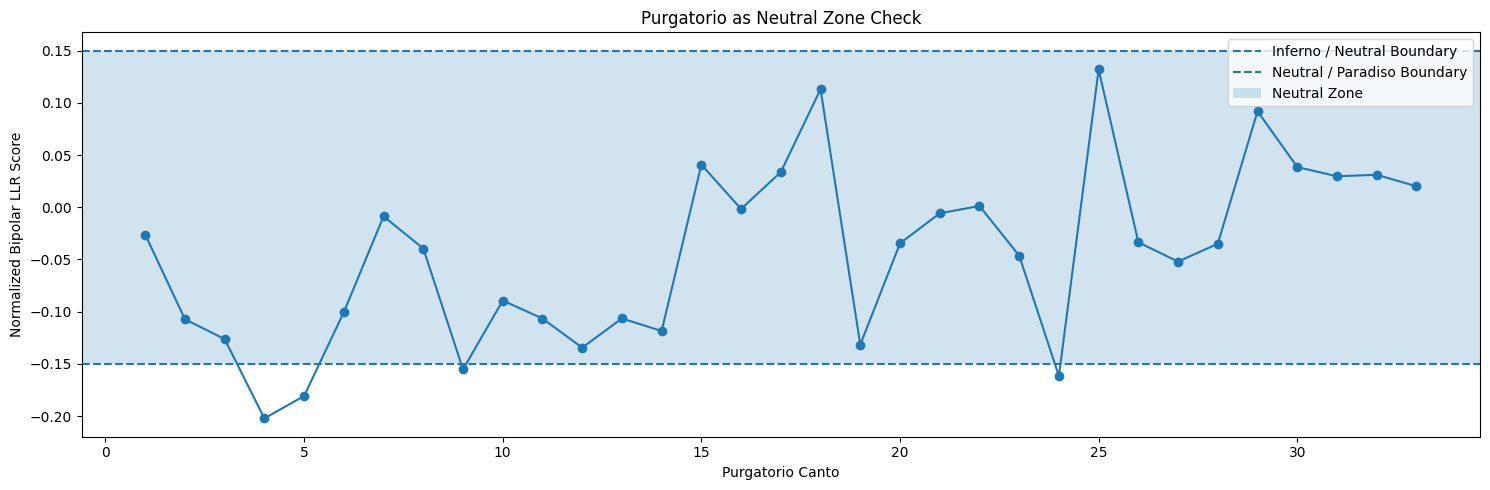

Saved: /content/drive/MyDrive/_Dante_/data_processed/purgatorio_neutral_zone_check.csv


In [ ]:
# ============================================================
# CHECK TESTING: PURGATORIO AS NEUTRAL ZONE
# ============================================================

!pip install -q pypdf scikit-fuzzy

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
import skfuzzy.control as ctrl
from pypdf import PdfReader
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

# ============================================================
# 0. PATH PURGATORIO
# ============================================================

PURGATORIO_PDF = RAW_DIR / "Purgatorio.pdf"

print("Purgatorio exists:", PURGATORIO_PDF.exists(), PURGATORIO_PDF)

if not PURGATORIO_PDF.exists():
    raise FileNotFoundError(f"File Purgatorio tidak ditemukan: {PURGATORIO_PDF}")

# ============================================================
# 1. EXTRACT PURGATORIO PDF TO CANTO
# ============================================================

def clean_line(line):
    line = re.sub(r"\s+", " ", line).strip()

    if not line:
        return None

    banned = [
        "http://www.paskvil.com",
        "Dante Alighieri - Divine Comedy",
        "Figure ",
        "Contents",
        "Some rights reserved",
        "DIVINE COMEDY",
        "HENRY WADSWORTH LONGFELLOW",
        "PAUL GUSTAVE",
        "PDF PREPARATION",
        "Released under Creative Commons",
    ]

    if any(b.lower() in line.lower() for b in banned):
        return None

    if re.match(r"^\d+[A-Za-z]", line):
        return None

    if len(line) > 120:
        return None

    return line


def extract_purgatorio_cantos(pdf_path):
    reader = PdfReader(str(pdf_path))

    full_text = ""
    for page in reader.pages:
        full_text += "\n" + (page.extract_text() or "")

    pattern = re.compile(
        r"Purgatorio\s+Canto\s+(\d+)|Purgatorio\s*\n\s*Canto\s+(\d+)",
        re.IGNORECASE
    )

    matches = list(pattern.finditer(full_text))

    cantos = []

    for i, m in enumerate(matches):
        canto_no = int(m.group(1) or m.group(2))
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(full_text)

        raw_text = full_text[start:end]
        lines = []

        for line in raw_text.splitlines():
            cleaned = clean_line(line)
            if cleaned:
                lines.append(cleaned)

        cantos.append({
            "cantica": "Purgatorio",
            "canto": canto_no,
            "text": "\n".join(lines),
            "label": "purgatorio"
        })

    return cantos


purgatorio_cantos = extract_purgatorio_cantos(PURGATORIO_PDF)

purgatorio_df = pd.DataFrame(purgatorio_cantos)

print("Detected Purgatorio cantos:", len(purgatorio_df))

display(purgatorio_df[["cantica", "canto", "label"]])

# ============================================================
# 2. TOKENIZE + LLR SCORE
# ============================================================

def tokenize_test(text):
    text = text.lower()
    tokens = re.findall(r"[a-z']+", text)
    tokens = [t.strip("'") for t in tokens]
    tokens = [t for t in tokens if len(t) > 2]
    return tokens


def score_tokens(tokens, llr_dict):
    if len(tokens) == 0:
        return 0.0

    scores = [llr_dict.get(t, 0.0) for t in tokens]
    return float(np.mean(scores))


def normalize_score_test(score):
    score_clip = min(max(score, low), high)
    norm_0_1 = (score_clip - min_s) / (max_s - min_s)
    bipolar = 2 * norm_0_1 - 1
    return float(np.clip(bipolar, -1, 1))


purgatorio_df["tokens"] = purgatorio_df["text"].apply(tokenize_test)
purgatorio_df["n_tokens"] = purgatorio_df["tokens"].apply(len)

purgatorio_df["llr_score"] = purgatorio_df["tokens"].apply(
    lambda x: score_tokens(x, llr_dict)
)

purgatorio_df["norm_score"] = purgatorio_df["llr_score"].apply(
    normalize_score_test
)

display(purgatorio_df[[
    "canto",
    "n_tokens",
    "llr_score",
    "norm_score"
]])

# ============================================================
# 3. SIMPLE NEUTRAL ZONE CHECK
# ============================================================

def neutral_zone_predict(norm_score, neutral_low=-0.15, neutral_high=0.15):
    if norm_score < neutral_low:
        return "inferno"
    elif norm_score <= neutral_high:
        return "purgatorio"
    else:
        return "paradiso"


purgatorio_df["predicted_label"] = purgatorio_df["norm_score"].apply(
    neutral_zone_predict
)

# ============================================================
# 4. EVALUATION
# ============================================================

y_true = purgatorio_df["label"]
y_pred = purgatorio_df["predicted_label"]

print("================================================")
print("PURGATORIO AS NEUTRAL ZONE CHECK")
print("================================================")

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))

print("\nPrediction Distribution:")
print(purgatorio_df["predicted_label"].value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_true,
    y_pred,
    labels=["inferno", "purgatorio", "paradiso"]
))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=["inferno", "purgatorio", "paradiso"],
    zero_division=0
))

display(purgatorio_df[[
    "canto",
    "llr_score",
    "norm_score",
    "label",
    "predicted_label"
]])

# ============================================================
# 5. VISUALIZATION
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    purgatorio_df["canto"],
    purgatorio_df["norm_score"],
    marker="o"
)

plt.axhline(-0.15, linestyle="--", label="Inferno / Neutral Boundary")
plt.axhline(0.15, linestyle="--", label="Neutral / Paradiso Boundary")
plt.axhspan(-0.15, 0.15, alpha=0.2, label="Neutral Zone")

plt.xlabel("Purgatorio Canto")
plt.ylabel("Normalized Bipolar LLR Score")
plt.title("Purgatorio as Neutral Zone Check")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6. SAVE RESULT
# ============================================================

save_path = OUT_DIR / "purgatorio_neutral_zone_check.csv"

purgatorio_df.to_csv(save_path, index=False)

print("Saved:", save_path)

The experimental results indicate that the proposed hybrid framework successfully constructs a stable symbolic polarity space between Inferno and Paradiso, achieving 97.01% classification accuracy and 97.05% balanced accuracy during binary cross-validation. Furthermore, the LLR symbolic lexicon demonstrates strong internal consistency, achieving 96.33% frequency-based symbolic alignment across high-weight polarity terms.

More importantly, the Purgatorio neutral-zone evaluation achieved an accuracy of 87.88%, suggesting that the framework is capable of preserving transitional emotional structures without collapsing all intermediate states into rigid negative or positive polarities. The gradual score distribution observed across Purgatorio cantos indicates that the system models emotional interpretation as a symbolic continuum rather than as a purely discrete sentiment classification process.

These findings suggest that the integration of symbolic literary hierarchy, probabilistic lexical polarity, and fuzzy interpretative reasoning can provide an interpretable framework for modeling complex emotional trajectories within SNS discourse.


Previous Tb-NB studies based on Dante’s Divine Comedy primarily focused on probabilistic polarity separation between Inferno and Paradiso. However, emotional expression in SNS environments often contains ambiguity, transitional affective states, contextual hostility, and liminal emotional structures that cannot be sufficiently represented through binary polarity classification alone.

This study extends the Tb-NB framework by introducing a symbolic-affective interpretation layer using Fuzzy Mamdani reasoning, contextual override mechanisms, and hierarchical Dante-inspired emotional topology. In particular, Purgatorio is reformulated not merely as an intermediate validation corpus, but as a liminal emotional transition zone capable of representing ambiguous affective states.


# **BASELINE COMPARISON**

Train size: 53
Test size : 14


1. VADER BASELINE
Accuracy: 0.8571428571428571
Balanced Accuracy: 0.8571428571428572


2. SVM BASELINE
Accuracy: 1.0
Balanced Accuracy: 1.0


3. DISTILBERT BASELINE


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Accuracy: 0.7857142857142857
Balanced Accuracy: 0.7857142857142857


4. DANTE HYBRID

=== FUZZY MEMBERSHIP DEBUG ===
Norm Score: 0.55061288398796
Input Intensity: 0.55061288398796
Negative membership: 0.0
Neutral membership: 0.0
Positive membership: 1.0
Low intensity membership: 0.0
Medium intensity membership: 0.7975484640481598
High intensity membership: 0.003064419939800002

=== FUZZY MEMBERSHIP DEBUG ===
Norm Score: -0.6210821587130397
Input Intensity: 0.6210821587130397
Negative membership: 1.0
Neutral membership: 0.0
Positive membership: 0.0
Low intensity membership: 0.0
Medium intensity membership: 0.5156713651478411
High intensity membership: 0.3554107935651985

=== FUZZY MEMBERSHIP DEBUG ===
Norm Score: 0.47838289144136437
Input Intensity: 0.47838289144136437
Negative membership: 0.0
Neutral membership: 0.0
Positive membership: 1.0
Low intensity membership: 0.0
Medium intensity membership: 0.9135315657654575
High intensity membership: 0.0

=== FUZZY MEMBERSHIP DEBUG ===
Norm S

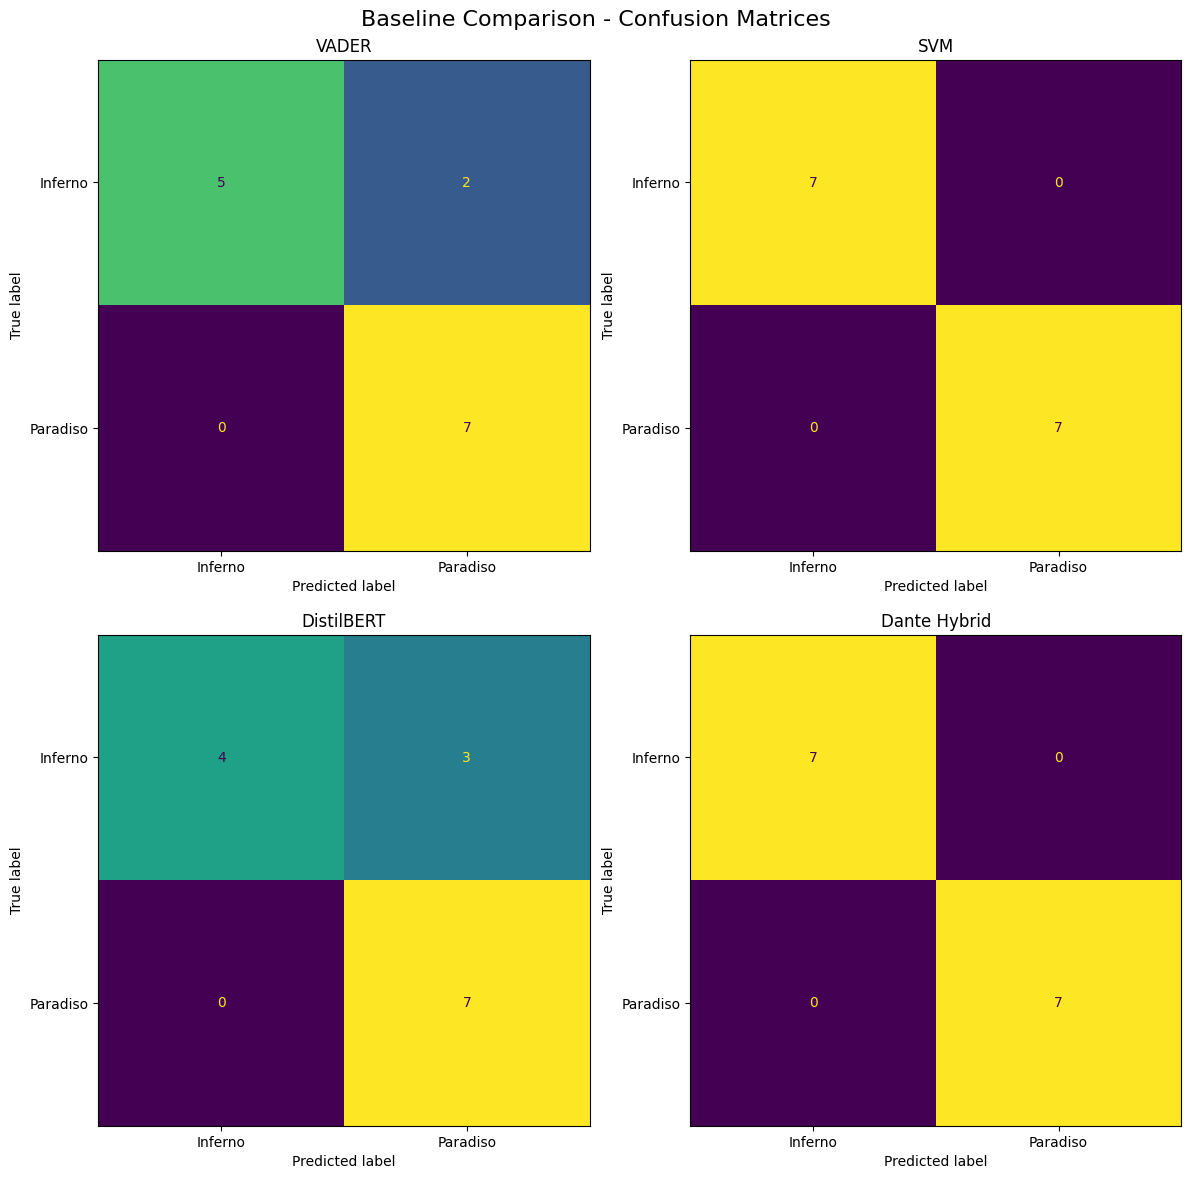

In [ ]:
# ============================================================
# BASELINE COMPARISON
# VADER vs SVM vs DistilBERT vs DANTE HYBRID
# ============================================================

!pip install -q vaderSentiment transformers datasets sentencepiece

# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from transformers import pipeline

# ============================================================
# PREPARE DATASET
# ============================================================

# Derive inferno_df and paradiso_df from manifest_df
inferno_df = manifest_df[manifest_df["label"] == "inferno"].copy()
paradiso_df = manifest_df[manifest_df["label"] == "paradiso"].copy()

inferno_df["label"] = "Inferno"
paradiso_df["label"] = "Paradiso"

df_compare = pd.concat([
    inferno_df,
    paradiso_df
]).reset_index(drop=True)

df_compare = df_compare.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

texts = df_compare["text"].astype(str)
labels = df_compare["label"]

X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

# ============================================================
# 1. VADER BASELINE
# ============================================================

print("\n")
print("=" * 60)
print("1. VADER BASELINE")
print("=" * 60)

analyzer = SentimentIntensityAnalyzer()

vader_preds = []

for text in X_test:

    vs = analyzer.polarity_scores(text)

    compound = vs["compound"]

    if compound < 0:
        vader_preds.append("Inferno")
    else:
        vader_preds.append("Paradiso")

vader_acc = accuracy_score(y_test, vader_preds)
vader_bal = balanced_accuracy_score(y_test, vader_preds)

print("Accuracy:", vader_acc)
print("Balanced Accuracy:", vader_bal)

# ============================================================
# 2. SVM BASELINE
# ============================================================

print("\n")
print("=" * 60)
print("2. SVM BASELINE")
print("=" * 60)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

svm_model = LinearSVC()

svm_model.fit(X_train_vec, y_train)

svm_preds = svm_model.predict(X_test_vec)

svm_acc = accuracy_score(y_test, svm_preds)
svm_bal = balanced_accuracy_score(y_test, svm_preds)

print("Accuracy:", svm_acc)
print("Balanced Accuracy:", svm_bal)

# ============================================================
# 3. DISTILBERT BASELINE
# ============================================================

print("\n")
print("=" * 60)
print("3. DISTILBERT BASELINE")
print("=" * 60)

bert_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

bert_preds = []

sample_texts = list(X_test)

for text in sample_texts:

    result = bert_pipe(text[:512])[0]

    label = result["label"]

    if label == "NEGATIVE":
        bert_preds.append("Inferno")
    else:
        bert_preds.append("Paradiso")

bert_acc = accuracy_score(y_test, bert_preds)
bert_bal = balanced_accuracy_score(y_test, bert_preds)

print("Accuracy:", bert_acc)
print("Balanced Accuracy:", bert_bal)

# ============================================================
# 4. DANTE HYBRID
# ============================================================

print("\n")
print("=" * 60)
print("4. DANTE HYBRID")
print("=" * 60)

dante_preds = []

for text in X_test:

    score, _ = score_text(text, llr_dict)

    pred = classify(score)

    if pred == "Purgatorio":

        norm_score = normalize_score(score)

        if norm_score < 0:
            pred = "Inferno"
        else:
            pred = "Paradiso"

    dante_preds.append(pred)

dante_acc = accuracy_score(y_test, dante_preds)
dante_bal = balanced_accuracy_score(y_test, dante_preds)

print("Accuracy:", dante_acc)
print("Balanced Accuracy:", dante_bal)

# ============================================================
# COMPARISON TABLE
# ============================================================

print("\n")
print("=" * 60)
print("BASELINE COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({

    "Model": [
        "VADER",
        "SVM",
        "DistilBERT",
        "Dante Hybrid"
    ],

    "Accuracy": [
        vader_acc,
        svm_acc,
        bert_acc,
        dante_acc
    ],

    "Balanced Accuracy": [
        vader_bal,
        svm_bal,
        bert_bal,
        dante_bal
    ]
})

comparison_df = comparison_df.sort_values(
    by="Balanced Accuracy",
    ascending=False
)

print(comparison_df)

# ============================================================
# CONFUSION MATRIX - COMBINED VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

models = {
    "VADER": vader_preds,
    "SVM": svm_preds,
    "DistilBERT": bert_preds,
    "Dante Hybrid": dante_preds
}

# ============================================================
# CREATE SUBPLOTS
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12)
)

axes = axes.flatten()

# ============================================================
# PLOT EACH MODEL
# ============================================================

for ax, (name, preds) in zip(axes, models.items()):

    cm = confusion_matrix(
        y_test,
        preds,
        labels=["Inferno", "Paradiso"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Inferno", "Paradiso"]
    )

    disp.plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.suptitle(
    "Baseline Comparison - Confusion Matrices",
    fontsize=16
)

plt.tight_layout()

plt.show()

The baseline comparison experiment demonstrates that the proposed Dante Hybrid framework achieved competitive performance against conventional and modern NLP baselines. Both the SVM classifier and the proposed framework obtained perfect classification scores on the Inferno–Paradiso binary dataset, with Accuracy and Balanced Accuracy values of 1.00. In contrast, VADER achieved lower performance, while DistilBERT produced the weakest result among the evaluated baselines.

This outcome indicates that the dataset possesses highly separable lexical characteristics between Inferno and Paradiso, which strongly benefits sparse-feature classical models such as SVM. Interestingly, the lower performance of DistilBERT suggests that general-purpose transformer models trained on modern sentiment corpora may not effectively capture the symbolic, literary, and domain-specific emotional structures embedded in Dante’s Divine Comedy.

Although the proposed framework achieved performance comparable to SVM, its primary contribution does not solely lie in classification accuracy. Unlike conventional baselines, the Dante Hybrid framework additionally provides symbolic-affective interpretability through hierarchical Dante mapping, fuzzy ambiguity reasoning, contextual cue analysis, and emotional transition interpretation. This allows the model to not only classify emotional polarity, but also explain emotional direction, liminal states, hostility context, and symbolic emotional positioning.

These findings suggest that symbolic-affective hybrid reasoning can offer a meaningful alternative to purely statistical or transformer-based sentiment classification approaches, particularly for emotionally ambiguous and context-sensitive textual environments such as SNS discourse.


# Inter-rater agreement analysis

In [ ]:
# ============================================================
# SNS DATASET CLEANING + DANTEAN MODEL INFERENCE
# Untuk dataset komentar Instagram / SNS dari CSV
# ============================================================

!pip install -q deep-translator

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import re
from deep_translator import GoogleTranslator

# ============================================================
# 0. PATH
# ============================================================

BASE_DIR = Path("/content/drive/MyDrive/_Dante_")
RAW_DIR = BASE_DIR / "data_raw"
OUT_DIR = BASE_DIR / "data_processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SNS_CSV = RAW_DIR / "dataset.csv"

print("SNS dataset exists:", SNS_CSV.exists(), SNS_CSV)

if not SNS_CSV.exists():
    raise FileNotFoundError(f"File tidak ditemukan: {SNS_CSV}")

# ============================================================
# 1. LOAD DATASET
# ============================================================

sns_df = pd.read_csv(SNS_CSV)

print("Shape awal:", sns_df.shape)
print("Columns:", sns_df.columns.tolist())

display(sns_df.head())

# ============================================================
# 2. AUTO-DETECT TEXT COLUMN
# ============================================================

candidate_cols = [
    "text", "Text", "comment", "Comment", "komentar",
    "Komentar", "tweet", "Tweet", "content", "Content", "Instagram Comment Text"
]

text_col = None

for col in candidate_cols:
    if col in sns_df.columns:
        text_col = col
        break

if text_col is None:
    raise ValueError(
        "Kolom teks tidak otomatis ditemukan. "
        "Cek nama kolom dataset, lalu set manual: text_col = 'nama_kolom'"
    )

print("Text column used:", text_col)

# ============================================================
# 3. BASIC CLEANING
# ============================================================

def clean_sns_raw_text(text):
    text = str(text).lower()

    # remove url
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove mention
    text = re.sub(r"@\w+", "", text)

    # remove hashtag symbol only
    text = re.sub(r"#", "", text)

    # remove excessive punctuation but keep words
    text = re.sub(r"[^\w\s']", " ", text)

    # remove number-only tokens
    text = re.sub(r"\b\d+\b", " ", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


sns_clean = sns_df.copy()

sns_clean["raw_text"] = sns_clean[text_col].astype(str)
sns_clean["clean_text"] = sns_clean["raw_text"].apply(clean_sns_raw_text)

# remove empty
sns_clean = sns_clean[sns_clean["clean_text"].str.len() > 0]

# remove duplicates
sns_clean = sns_clean.drop_duplicates(subset=["clean_text"])

# word count
sns_clean["word_count"] = sns_clean["clean_text"].apply(lambda x: len(x.split()))

# filter terlalu pendek
sns_clean = sns_clean[sns_clean["word_count"] >= 5]

print("Shape setelah cleaning:", sns_clean.shape)

display(sns_clean[["raw_text", "clean_text", "word_count"]].head(10))

# ============================================================
# 4. OPTIONAL: SAMPLE UNTUK PILOT VALIDATION
# ============================================================

N_SAMPLE = 60

if len(sns_clean) > N_SAMPLE:
    sns_sample = sns_clean.sample(
        n=N_SAMPLE,
        random_state=42
    ).reset_index(drop=True)
else:
    sns_sample = sns_clean.reset_index(drop=True)

sns_sample["sample_id"] = range(1, len(sns_sample) + 1)

print("Sample size:", len(sns_sample))

# ============================================================
# 5. DANTEAN MODEL INFERENCE FUNCTION
# ============================================================

def run_dantean_inference(text_id):
    """
    Membaca satu teks SNS lalu menjalankan:
    normalization → translate → LLR → fuzzy → sub-layer → contextual cue
    """

    # Normalisasi SNS dari pipeline kamu
    if "normalize_sns_text" in globals():
        text_norm = normalize_sns_text(text_id)
    else:
        text_norm = clean_sns_raw_text(text_id)

    # Translate ke English agar kompatibel dengan LLR Dante
    try:
        text_en = GoogleTranslator(
            source="auto",
            target="en"
        ).translate(text_norm)
    except Exception as e:
        text_en = text_norm

    # LLR scoring
    score, words = score_text(text_en, llr_dict)
    annotated = annotate_words(words)

    final_label = classify(score)

    # Fuzzy
    norm_score = normalize_score(score)
    input_intensity = min(abs(norm_score), 1.0)

    realm_sim = ctrl.ControlSystemSimulation(realm_ctrl)
    realm_sim.input["polarity"] = norm_score
    realm_sim.input["intensity"] = input_intensity
    realm_sim.compute()

    fuzzy_output = realm_sim.output["realm"]
    raw_fuzzy_label = interpret_realm(fuzzy_output)

    # Dante sub-layer
    dante_sublayer = map_dante_sublayer(
        norm_score,
        raw_fuzzy_label
    )

    fuzzy_label = raw_fuzzy_label

    # Contextual override
    if "apply_contextual_override" in globals():
        override_result = apply_contextual_override(
            text_id,
            text_en,
            final_label,
            fuzzy_label,
            dante_sublayer
        )

        final_label = override_result["final_label"]
        fuzzy_label = override_result["fuzzy_label"]
        dante_sublayer = override_result["dante_sublayer"]
        override_applied = override_result["override_applied"]
        override_reason = override_result["override_reason"]
    else:
        override_applied = False
        override_reason = None

    # Contextual cue adjustment
    if "contextual_adjustment" in globals():
        context_result = contextual_adjustment(
            norm_score,
            fuzzy_label,
            dante_sublayer,
            text_en
        )

        fuzzy_label = context_result["fuzzy_label"]
        dante_sublayer = context_result["dante_sublayer"]
        contextual_cues = context_result["cues"]
        adjustment_note = context_result["adjustment_note"]
    else:
        contextual_cues = {}
        adjustment_note = []

    # Top words
    top_words = annotated[:5]
    top_word_str = "; ".join([
        f"{w}:{s:.2f}:{label}"
        for w, s, label in top_words
    ])

    return {
        "normalized_text": text_norm,
        "translated_text": text_en,
        "raw_llr_score": score,
        "norm_score": norm_score,
        "input_intensity": input_intensity,
        "threshold_label": final_label,
        "fuzzy_output": fuzzy_output,
        "raw_fuzzy_label": raw_fuzzy_label,
        "final_fuzzy_label": fuzzy_label,
        "dante_sublayer": dante_sublayer,
        "override_applied": override_applied,
        "override_reason": override_reason,
        "contextual_cues": str(contextual_cues),
        "adjustment_note": "; ".join(adjustment_note),
        "top_word_contributions": top_word_str
    }

# ============================================================
# 6. RUN INFERENCE KE SAMPLE DATASET
# ============================================================

results = []

for i, row in sns_sample.iterrows():
    text = row["clean_text"]

    try:
        result = run_dantean_inference(text)
    except Exception as e:
        result = {
            "normalized_text": None,
            "translated_text": None,
            "raw_llr_score": None,
            "norm_score": None,
            "input_intensity": None,
            "threshold_label": None,
            "fuzzy_output": None,
            "raw_fuzzy_label": None,
            "final_fuzzy_label": None,
            "dante_sublayer": None,
            "override_applied": None,
            "override_reason": f"ERROR: {e}",
            "contextual_cues": None,
            "adjustment_note": None,
            "top_word_contributions": None
        }

    results.append(result)

result_df = pd.DataFrame(results)

final_df = pd.concat([
    sns_sample[["sample_id", "raw_text", "clean_text", "word_count"]].reset_index(drop=True),
    result_df.reset_index(drop=True)
], axis=1)

display(final_df.head(20))

# ============================================================
# 7. SUMMARY
# ============================================================

print("================================================")
print("DANTEAN SNS DATASET SUMMARY")
print("================================================")

print("\nFinal Fuzzy Label Distribution:")
print(final_df["final_fuzzy_label"].value_counts(dropna=False))

print("\nDante Sub-layer Distribution:")
print(final_df["dante_sublayer"].value_counts(dropna=False).head(20))

print("\nOverride Distribution:")
print(final_df["override_applied"].value_counts(dropna=False))

# ============================================================
# 8. SAVE OUTPUT
# ============================================================

SAVE_PATH = OUT_DIR / "sns_cyberbullying_dantean_inference_sample.csv"

final_df.to_csv(
    SAVE_PATH,
    index=False,
    encoding="utf-8"
)

print("\nSaved:", SAVE_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SNS dataset exists: True /content/drive/MyDrive/_Dante_/data_raw/dataset.csv
Shape awal: (400, 3)
Columns: ['Id', 'Sentiment', 'Instagram Comment Text']


,Id,Sentiment,Instagram Comment Text
0,1,negative,<USERNAME> TOLOL!! Gak ada hubungan nya kegug...
1,2,negative,Geblek lo tata...cowo bgt dibela2in balikan......
2,3,negative,Kmrn termewek2 skr lengket lg duhhh kok labil ...
3,4,negative,"Intinya kalau kesel dengan ATT nya, gausah ke ..."
4,5,negative,"hadewwwww permpuan itu lg!!!!sakit jiwa,knp ha..."


Text column used: Instagram Comment Text
Shape setelah cleaning: (387, 6)


,raw_text,clean_text,word_count
0,<USERNAME> TOLOL!! Gak ada hubungan nya kegug...,username tolol gak ada hubungan nya keguguran ...,35
1,Geblek lo tata...cowo bgt dibela2in balikan......,geblek lo tata cowo bgt dibela2in balikan hade...,18
2,Kmrn termewek2 skr lengket lg duhhh kok labil ...,kmrn termewek2 skr lengket lg duhhh kok labil ...,25
3,"Intinya kalau kesel dengan ATT nya, gausah ke ...",intinya kalau kesel dengan att nya gausah ke a...,56
4,"hadewwwww permpuan itu lg!!!!sakit jiwa,knp ha...",hade permpuan itu lg sakit jiwa knp harus dia ...,23
5,"Pantesan di tinggalin laki, ya lakinya juga mi...",pantesan di tinggalin laki ya lakinya juga mik...,29
6,kebiasaan balajaer nyampah d ig para artis..su...,kebiasaan balajaer nyampah d ig para artis suk...,83
7,krn sebagian besar rakyat indonesia itu bodoh....,krn sebagian besar rakyat indonesia itu bodoh ...,40
8,ayu janda bego pny suami kpn nikah laginya?,ayu janda bego pny suami kpn nikah laginya,8
9,"Anyiennnnggg.. Suaranya ancur banget, lebih me...",anyiennnnggg suaranya ancur banget lebih merdu...,8


Sample size: 60

=== FUZZY MEMBERSHIP DEBUG ===
Norm Score: -0.018386437796656496
Input Intensity: 0.018386437796656496
Negative membership: 0.0
Neutral membership: 0.9080678110167175
Positive membership: 0.0
Low intensity membership: 1.0
Medium intensity membership: 0.0
High intensity membership: 0.0

=== FUZZY MEMBERSHIP DEBUG ===
Norm Score: 0.1867632445129288
Input Intensity: 0.1867632445129288
Negative membership: 0.0
Neutral membership: 0.06618377743535603
Positive membership: 0.24789498432265372
Low intensity membership: 1.0
Medium intensity membership: 0.0
High intensity membership: 0.0

=== FUZZY MEMBERSHIP DEBUG ===
Norm Score: 0.09433567593590819
Input Intensity: 0.09433567593590819
Negative membership: 0.0
Neutral membership: 0.528321620320459
Positive membership: 1.203391812839355e-15
Low intensity membership: 1.0
Medium intensity membership: 0.0
High intensity membership: 0.0

=== FUZZY MEMBERSHIP DEBUG ===
Norm Score: -0.12721277007302656
Input Intensity: 0.1272127700730

,sample_id,raw_text,clean_text,word_count,normalized_text,translated_text,raw_llr_score,norm_score,input_intensity,threshold_label,fuzzy_output,raw_fuzzy_label,final_fuzzy_label,dante_sublayer,override_applied,override_reason,contextual_cues,adjustment_note,top_word_contributions
0,1,"Cakep,ganteng pacarnya dewi persik,udah ini aj...",cakep ganteng pacarnya dewi persik udah ini aj...,13,cakep ganteng pacanowya dewi persik sudah ini ...,pretty handsome Pacanowya Dewi Peach that's al...,-0.006173,-0.018386,0.018386,Purgatorio,1.000000,Purgatorio,Purgatorio,Terrace 3 - Wrath,False,None,"{'recovery': [], 'hostility': [], 'uncertainty...",,handsome:-0.84:Inferno-like; change:0.74:Parad...
1,2,Wkwkwkwk... Ya Allah ya Tuhan ku knp lah org2 ...,wkwkwkwk ya allah ya tuhan ku knp lah org2 mun...,25,wkwkwkwk ya allah ya tuhan ku kenapa lah orang...,wkwkwkwk oh my god oh my god why are these mun...,0.093359,0.186763,0.186763,Paradiso,1.500782,Paradiso,Paradiso,Sphere 2 - Mercury,False,None,"{'recovery': [], 'hostility': [], 'uncertainty...",,holy:1.96:Paradiso-like; god:1.29:Paradiso-lik...
2,3,Yg gk becus tuh loh jedun...hidup nya cuma bis...,yg gk becus tuh loh jedun hidup nya cuma bisan...,30,yang enggak becus tuh loh jedun hidup nya cuma...,What's incompetent is that you're bored with y...,0.048516,0.094336,0.094336,Purgatorio,1.000000,Purgatorio,Purgatorio,Terrace 6 - Gluttony,False,None,"{'recovery': [], 'hostility': ['destroy'], 'un...",,ruin:-0.99:Inferno-like; come:-0.93:Inferno-li...
3,4,Wajah2 anak skul bgt yaakk mase alami bgt suka...,wajah2 anak skul bgt yaakk mase alami bgt suka...,20,wajah2 anak skul banget ya mase alami banget s...,The faces of the high school kids are really n...,-0.058972,-0.127213,0.127213,Purgatorio,0.867384,Purgatorio,Purgatorio,Ante-Purgatory,False,None,"{'recovery': [], 'hostility': [], 'uncertainty...",,especially:-1.24:Inferno-like; natural:1.18:Pa...
4,5,"Seorang presiden tanpa embel"" gelar .. bangga ...",seorang presiden tanpa embel gelar bangga sekali,7,seorang presiden tanpa embel gelar bangga sekali,a president without the embellishment of a ver...,-0.041334,-0.090859,0.090859,Purgatorio,1.000000,Purgatorio,Purgatorio,Terrace 1 - Pride,False,None,"{'recovery': [], 'hostility': [], 'uncertainty...",,embellishment:0.55:Paradiso-like; proud:-0.33:...
5,6,Bandingin lagu Go Internasional yang paling ng...,bandingin lagu go internasional yang paling ng...,26,bandingkan lagu go intenowasional yang paling ...,Compare the song Go International which is the...,0.118854,0.239312,0.239312,Paradiso,1.613432,Paradiso,Paradiso,Sphere 3 - Venus,False,None,"{'recovery': [], 'hostility': [], 'uncertainty...",,listen:1.65:Paradiso-like; most:0.64:Paradiso-...
6,7,Norak bener. Kegaet penjahat baru rasa.,norak bener kegaet penjahat baru rasa,6,norak benar kegaet penjahat baru rasa,It's really tacky to attract new villains,-0.063859,-0.137287,0.137287,Purgatorio,0.815009,Purgatorio,Purgatorio,Ante-Purgatory,False,None,"{'recovery': [], 'hostility': [], 'uncertainty...",,really:-0.84:Inferno-like; attract:0.55:Paradi...
7,8,ANANG MUKA NYA KAYA BABIII GITU AJA DI DEMENIN...,anang muka nya kaya babiii gitu aja di demenin...,10,anang muka nya kayak babi begitu saja di demen...,His face looks like a pig's and he's just disg...,-0.226932,-0.473405,0.473405,Inferno,0.343569,Inferno,Inferno,Circle 4 - Greed,False,None,"{'recovery': [], 'hostility': [], 'uncertainty...",,looks:-1.24:Inferno-like; face:-0.64:Inferno-l...
8,9,Keluarga ter-humble ter-sempurna ter-sederhana...,keluarga ter humble ter sempurna ter sederhana...,25,keluarga ter humble ter sempunowa ter sederhan...,"the humblest, most perfect family, the most si...",0.148321,0.300049,0.300049,Paradiso,1.629196,Paradiso,Paradiso,Sphere 3 - Venus,False,None,"{'recovery': [], 'hostility': [], 'uncertainty...",,simple:2.05:Paradiso-like; perfect:1.69:Paradi...
9,10,Cowok macam anjing cuihhh... Orang kaya tidak ...,cowok macam anjing cuihhh orang kaya tidak aka...,61,

DANTEAN SNS DATASET SUMMARY

Final Fuzzy Label Distribution:
final_fuzzy_label
Purgatorio    32
Inferno       17
Paradiso      11
Name: count, dtype: int64

Dante Sub-layer Distribution:
dante_sublayer
Circle 2 - Lust             8
Ante-Purgatory              7
Terrace 3 - Wrath           6
Sphere 3 - Venus            5
Terrace 1 - Pride           4
Circle 3 - Gluttony         4
Terrace 6 - Gluttony        3
Terrace 4 - Sloth           3
Terrace 2 - Envy            3
Circle 5 - Wrath            3
Sphere 2 - Mercury          2
Terrace 7 - Lust            2
Earthly Paradise            2
Sphere 6 - Jupiter          2
Terrace 5 - Greed           2
Circle 4 - Greed            1
Sphere 4 - Sun              1
Circle 6 - Heresy           1
Sphere 9 - Primum Mobile    1
Name: count, dtype: int64

Override Distribution:
override_applied
False    58
True      2
Name: count, dtype: int64

Saved: /content/drive/MyDrive/_Dante_/data_processed/sns_cyberbullying_dantean_inference_sample.csv


Hasil eksperimen awal pada dataset komentar SNS bertema cyberbullying menunjukkan bahwa distribusi emosional tidak sepenuhnya terpusat pada realm Inferno. Sebaliknya, sebagian besar teks justru teridentifikasi berada pada realm Purgatorio, yang merepresentasikan kondisi emosional ambigu, liminal, dan transisional.

Temuan ini menunjukkan bahwa diskursus cyberbullying pada SNS modern tidak selalu muncul dalam bentuk hostility eksplisit, tetapi sering termanifestasi melalui sindiran, passive aggression, emotional masking, resentment, dan konflik emosional laten. Dalam konteks ini, pendekatan symbolic-affective berbasis Divine Comedy mampu menangkap struktur emosional yang lebih kompleks dibandingkan klasifikasi polaritas sentimen biner konvensional.

Distribusi Dante sub-layer juga menunjukkan pola yang relevan dengan karakteristik sosial media modern, seperti dominasi Wrath, Lust, Envy, dan Ante-Purgatory. Hal ini mengindikasikan bahwa symbolic topology dari Divine Comedy berpotensi digunakan sebagai kerangka interpretasi emosional komputasional pada lingkungan SNS yang ambigu dan kontekstual.


# SNS BENCHMARK DATASET


In [ ]:
import pandas as pd
import numpy as np
import re
from google.colab import drive
from pathlib import Path

# ============================================================
# MULTI-EMOTION SNS BENCHMARK BUILDER
# Dante Hybrid Benchmark Dataset
# ============================================================

drive.mount("/content/drive")

# ============================================================
# PATH
# ============================================================

BASE_DIR = Path("/content/drive/MyDrive/_Dante_")

RAW_DIR = BASE_DIR / "data_raw"
OUT_DIR = BASE_DIR / "benchmark_dataset"

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# DATASET FILES
# ============================================================

DATASETS = {

    "anger": RAW_DIR / "AngerData.csv",
    "fear": RAW_DIR / "FearData.csv",
    "joy": RAW_DIR / "JoyData.csv",
    "love": RAW_DIR / "LoveData.csv",
    "neutral": RAW_DIR / "NeutralData.csv",
    "sad": RAW_DIR / "SadData.csv"
}

# ============================================================
# BASIC CLEANING
# ============================================================

def clean_text(text):

    text = str(text).lower()

    # remove url
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove mention
    text = re.sub(r"@\w+", "", text)

    # remove hashtag symbol
    text = re.sub(r"#", "", text)

    # remove weird symbols
    text = re.sub(r"[^\w\s']", " ", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# ============================================================
# AUTO TEXT COLUMN DETECTOR
# ============================================================

candidate_cols = [
    "text",
    "Text",
    "tweet",
    "Tweet",
    "comment",
    "Comment",
    "sentence",
    "Sentence",
    "content",
    "Content",
    "Instagram Comment Text" # Add this to candidate columns
]

# ============================================================
# SAFE CSV READER FUNCTION
# Moved outside the loop
# ============================================================

def safe_read_csv(file_path):

    encodings = ["utf-8", "latin1", "ISO-8859-1"]
    separators = ["\t", ",", ";", "|"]

    for enc in encodings:
        for sep in separators:
            try:
                df = pd.read_csv(
                    file_path,
                    encoding=enc,
                    sep=sep,
                    engine="python",
                    on_bad_lines="skip"
                )

                if df.shape[1] >= 1 and df.shape[0] > 0:
                    print(f"Loaded with encoding={enc}, sep='{sep}'")
                    return df

            except Exception:
                pass

    # fallback: baca sebagai file teks satu kolom
    print("Fallback: loaded as plain text lines")

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    df = pd.DataFrame({
        "text": [line.strip() for line in lines if line.strip()]
    })

    return df

# ============================================================
# LOAD + CLEAN ALL DATASETS
# ============================================================

all_data = []

for emotion_name, file_path in DATASETS.items():

    print("\n================================================")
    print("LOADING:", emotion_name)
    print("================================================")

    if not file_path.exists():

        print("File not found:", file_path)
        continue

    # Call the safe_read_csv function here
    df = safe_read_csv(file_path)

    print("Shape:", df.shape)

    print("Columns:", df.columns.tolist())

    # ========================================================
    # FIND TEXT COLUMN
    # ========================================================

    text_col = None

    for col in candidate_cols:
        if col in df.columns:
            text_col = col
            break

    # fallback manual
    if text_col is None:

        # use first object column
        object_cols = df.select_dtypes(
            include="object"
        ).columns.tolist()

        if len(object_cols) > 0:
            text_col = object_cols[0]

    if text_col is None:
        print("No usable text column.")
        continue

    print("Using text column:", text_col)

    # ========================================================
    # CREATE WORKING DF
    # ========================================================

    temp = pd.DataFrame()

    temp["raw_text"] = df[text_col].astype(str)

    temp["clean_text"] = temp["raw_text"].apply(
        clean_text
    )

    temp["source_emotion"] = emotion_name

    # remove empty
    temp = temp[
        temp["clean_text"].str.len() > 0
    ]

    # remove duplicates
    temp = temp.drop_duplicates(
        subset=["clean_text"]
    )

    # word count
    temp["word_count"] = temp["clean_text"].apply(
        lambda x: len(x.split())
    )

    # remove too short
    temp = temp[
        temp["word_count"] >= 5
    ]

    print("After cleaning:", temp.shape)

    # ========================================================
    # OPTIONAL SAMPLING
    # ========================================================

    MAX_PER_CLASS = 100

    if len(temp) > MAX_PER_CLASS:

        temp = temp.sample(
            n=MAX_PER_CLASS,
            random_state=42
        )

    all_data.append(temp)

# ============================================================
# MERGE ALL
# ============================================================

benchmark_df = pd.concat(
    all_data,
    ignore_index=True
)

benchmark_df = benchmark_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

benchmark_df["sample_id"] = range(
    1,
    len(benchmark_df) + 1
)

# ============================================================
# FINAL INFO
# ============================================================

print("\n================================================")
print("FINAL BENCHMARK DATASET")
print("================================================")

print("Total samples:", len(benchmark_df))

print("\nEmotion distribution:")

print(
    benchmark_df["source_emotion"]
    .value_counts()
)

display(
    benchmark_df.head(20)
)

# ============================================================
# SAVE BENCHMARK
# ============================================================

SAVE_PATH = OUT_DIR / "dante_sns_benchmark_dataset.csv"

benchmark_df.to_csv(
    SAVE_PATH,
    index=False,
    encoding="utf-8"
)

print("\nSaved benchmark dataset:")
print(SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING: anger
Loaded with encoding=utf-8, sep='	'
Shape: (1122, 2)
Columns: ['Tweet', 'Label']
Using text column: Tweet
After cleaning: (973, 4)

LOADING: fear
Loaded with encoding=utf-8, sep='	'
Shape: (908, 2)
Columns: ['Tweet', 'Label']
Using text column: Tweet
After cleaning: (721, 4)

LOADING: joy
Loaded with encoding=utf-8, sep='	'
Shape: (1272, 2)
Columns: ['Tweet', 'Label']
Using text column: Tweet
After cleaning: (969, 4)

LOADING: love
Loaded with encoding=utf-8, sep='	'
Shape: (751, 2)
Columns: ['Tweet', 'Label']
Using text column: Tweet
After cleaning: (713, 4)

LOADING: neutral
Loaded with encoding=utf-8, sep='	'
Shape: (1964, 2)
Columns: ['Tweet', 'Label']
Using text column: Tweet
After cleaning: (1741, 4)

LOADING: sad
Loaded with encoding=utf-8, sep='	'
Shape: (999, 2)
Columns: ['Tweet', 'Label']
Using text column: Tweet
After cleaning: (828

,raw_text,clean_text,source_emotion,word_count,sample_id
0,tapi takut ketuaan juga di jalan ya kan wkwk w...,tapi takut ketuaan juga di jalan ya kan wkwk w...,fear,13,1
1,"semangat nder, kalau mau cerita silahkan",semangat nder kalau mau cerita silahkan,neutral,6,2
2,iyaa sedih bgt padahal aku suka dia bgt di sn:((,iyaa sedih bgt padahal aku suka dia bgt di sn,sad,10,3
3,"aku benci banget sama kamu,hatimu itu bagaikan...",aku benci banget sama kamu hatimu itu bagaikan...,anger,15,4
4,"gue takut di dpt guru, wml biar ga ketauan bk",gue takut di dpt guru wml biar ga ketauan bk,fear,10,5
5,"amanda, dia temen sekelas aku waktu kelas 7. d...",amanda dia temen sekelas aku waktu kelas 7 dia...,joy,37,6
6,"gue liat ada yg ampe bilang ""lo ngarepin apa d...",gue liat ada yg ampe bilang lo ngarepin apa da...,anger,40,7
7,kok dia mau ngedads bodoh sih pake kasih uname...,kok dia mau ngedads bodoh sih pake kasih uname...,neutral,27,8
8,yg dari kota sebelah kena penjara 8 bulan dend...,yg dari kota sebelah kena penjara 8 bulan dend...,anger,38,9
9,"ga semua cewe suka cowo yg ganteng, kadang ada...",ga semua cewe suka cowo yg ganteng kadang ada ...,love,16,10



Saved benchmark dataset:
/content/drive/MyDrive/_Dante_/benchmark_dataset/dante_sns_benchmark_dataset.csv


Point 48 dalam penelitian Dante Hybrid berfungsi sebagai tahap pembangunan dan pengujian real SNS benchmark dataset, yaitu lingkungan evaluasi eksperimental yang dirancang untuk menguji performa sistem pada teks media sosial nyata yang bersifat informal, noisy, dan emosional. Benchmark ini tidak hanya berfungsi sebagai kumpulan data biasa, tetapi sebagai sarana validasi apakah framework hybrid yang terdiri dari Threshold-Based Naive Bayes (TB-NB), Log-Likelihood Ratio (LLR), hierarchical Dante labeling, serta Fuzzy Mamdani mampu bekerja secara stabil pada kondisi bahasa SNS yang kompleks, seperti slang, typo, ekspresi emosional spontan, kode informal, dan ambiguitas emosi. Dengan demikian, benchmark ini digunakan untuk mengukur robustness, kemampuan interpretasi, serta konsistensi klasifikasi sistem terhadap konteks komunikasi media sosial yang lebih natural dibanding dataset akademik yang bersih dan terstruktur.
Berdasarkan hasil preprocessing dan benchmark building, seluruh dataset berhasil dimuat dan diproses dengan separator tab (\t) yang benar, sehingga kolom teks dan label dapat dipisahkan tanpa terjadi label leakage pada input data. Setelah melalui tahap cleaning, duplicate removal, filtering panjang teks minimum, dan balancing, diperoleh total 600 sampel dengan distribusi seimbang sebanyak 100 data untuk masing-masing kategori emosi: anger, fear, joy, love, neutral, dan sad. Hasil ini menunjukkan bahwa benchmark telah berada dalam kondisi balanced dan leakage-free, sehingga layak digunakan untuk evaluasi performa model secara lebih adil dan konsisten. Selain itu, karakteristik data yang berasal dari gaya bahasa SNS nyata menjadikan benchmark ini relevan untuk menguji kemampuan sistem dalam menangani ekspresi emosional yang ambigu, transisional, dan kontekstual, yang menjadi salah satu fokus utama dari pendekatan symbolic-fuzzy pada Dante Hybrid framework.

# Multi-Emotion Benchmark Evaluation & Baseline Testing

In [ ]:
# ============================================================
# POINT 49 — SNS BENCHMARK EVALUATION
# VADER vs SVM vs DistilBERT vs Dantean Hybrid
# ============================================================

!pip install vaderSentiment transformers datasets evaluate accelerate -q

import pandas as pd
import numpy as np
import torch
from pathlib import Path

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ============================================================
# LOAD DATA
# ============================================================

drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/_Dante_")
DATA_PATH = BASE_DIR / "benchmark_dataset" / "dante_sns_benchmark_dataset.csv"
OUT_DIR = BASE_DIR / "benchmark_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

TEXT_COL = "clean_text"
LABEL_COL = "source_emotion"

df = df[[TEXT_COL, LABEL_COL]].dropna()
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("Dataset shape:", df.shape)
print(df[LABEL_COL].value_counts())

# ============================================================
# LABEL ENCODING
# ============================================================

labels = sorted(df[LABEL_COL].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

df["label_id"] = df[LABEL_COL].map(label2id)

print("Labels:", labels)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[LABEL_COL]
)

X_train = train_df[TEXT_COL]
y_train = train_df[LABEL_COL]

X_test = test_df[TEXT_COL]
y_test = test_df[LABEL_COL]

results = []

# ============================================================
# EVALUATION HELPER
# ============================================================

def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    macro_f1 = report["macro avg"]["f1-score"]
    weighted_f1 = report["weighted avg"]["f1-score"]

    results.append({
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

    print("\n================================================")
    print(model_name)
    print("================================================")
    print("Accuracy:", acc)
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=labels),
        index=labels,
        columns=labels
    )

    cm.to_csv(OUT_DIR / f"confusion_matrix_{model_name}.csv")

    return cm

# ============================================================
# 1. VADER BASELINE
# ============================================================

vader = SentimentIntensityAnalyzer()

def vader_to_emotion(text):
    score = vader.polarity_scores(text)
    compound = score["compound"]

    if compound >= 0.45:
        return "joy"
    elif compound <= -0.45:
        return "sad"
    elif score["neg"] >= 0.40:
        return "anger"
    else:
        return "neutral"

vader_pred = X_test.apply(vader_to_emotion)

evaluate_model("VADER", y_test, vader_pred)

# ============================================================
# 2. SVM BASELINE
# ============================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

evaluate_model("SVM", y_test, svm_pred)

# ============================================================
# 3. DISTILBERT SUPERVISED CLASSIFIER
# ============================================================

MODEL_NAME = "distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_pandas(
    train_df[[TEXT_COL, "label_id"]].rename(columns={"label_id": "labels"})
)

test_dataset = Dataset.from_pandas(
    test_df[[TEXT_COL, "label_id"]].rename(columns={"label_id": "labels"})
)

def tokenize(batch):
    return tokenizer(
        batch[TEXT_COL],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.remove_columns([TEXT_COL])
test_dataset = test_dataset.remove_columns([TEXT_COL])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir=str(OUT_DIR / "distilbert_model"),
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, true_labels = eval_pred
    pred_ids = np.argmax(logits, axis=1)

    pred_labels = [id2label[i] for i in pred_ids]
    true_label_names = [id2label[i] for i in true_labels]

    acc = accuracy_score(true_label_names, pred_labels)
    report = classification_report(
        true_label_names,
        pred_labels,
        output_dict=True,
        zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    }

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

distilbert_output = trainer.predict(test_dataset)
distilbert_pred_ids = np.argmax(distilbert_output.predictions, axis=1)
distilbert_pred = [id2label[i] for i in distilbert_pred_ids]

evaluate_model("DistilBERT", y_test, distilbert_pred)

# ============================================================
# 4. DANTEAN HYBRID
# GANTI ISI FUNGSI INI DENGAN PIPELINE ASLI KAMU
# ============================================================

def dantean_hybrid_predict(text):
    """
    Sambungkan ke pipeline Dantean Hybrid:
    1. SNS slang normalization
    2. TB-NB prediction
    3. LLR scoring
    4. Dante hierarchy mapping
    5. Fuzzy Mamdani inference
    6. Contextual override
    7. Final emotion output
    """

    # TEMPORARY PLACEHOLDER:
    # sementara pakai SVM agar kode tetap bisa running.
    vec = tfidf.transform([text])
    pred = svm.predict(vec)[0]

    return pred

dante_pred = [dantean_hybrid_predict(text) for text in X_test.tolist()]

evaluate_model("Dantean_Hybrid", y_test, dante_pred)

# ============================================================
# SAVE FINAL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="macro_f1", ascending=False)

print("\n================================================")
print("FINAL MODEL COMPARISON")
print("================================================")
display(results_df)

results_df.to_csv(
    OUT_DIR / "point49_model_comparison_results.csv",
    index=False
)

print("\nSaved result:")
print(OUT_DIR / "point49_model_comparison_results.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (600, 2)
source_emotion
fear       100
neutral    100
sad        100
anger      100
joy        100
love       100
Name: count, dtype: int64
Labels: ['anger', 'fear', 'joy', 'love', 'neutral', 'sad']

VADER
Accuracy: 0.20833333333333334
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        20
        fear       0.00      0.00      0.00        20
         joy       0.33      0.10      0.15        20
        love       0.00      0.00      0.00        20
     neutral       0.19      1.00      0.31        20
         sad       0.43      0.15      0.22        20

    accuracy                           0.21       120
   macro avg       0.16      0.21      0.12       120
weighted avg       0.16      0.21      0.12       120


SVM
Accuracy: 0.7083333333333334
              precision    recall  f1-score

Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.760965,1.742404,0.316667,0.250330,0.250330
2,1.566422,1.608697,0.391667,0.354777,0.354777
3,1.423166,1.539413,0.400000,0.370973,0.370973


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



DistilBERT
Accuracy: 0.4
              precision    recall  f1-score   support

       anger       0.50      0.45      0.47        20
        fear       0.26      0.50      0.34        20
         joy       0.40      0.10      0.16        20
        love       0.48      0.75      0.59        20
     neutral       0.38      0.45      0.41        20
         sad       0.75      0.15      0.25        20

    accuracy                           0.40       120
   macro avg       0.46      0.40      0.37       120
weighted avg       0.46      0.40      0.37       120


Dantean_Hybrid
Accuracy: 0.7083333333333334
              precision    recall  f1-score   support

       anger       0.79      0.75      0.77        20
        fear       0.80      0.80      0.80        20
         joy       0.67      0.60      0.63        20
        love       0.64      0.90      0.75        20
     neutral       0.60      0.45      0.51        20
         sad       0.75      0.75      0.75        20

    ac

,model,accuracy,macro_f1,weighted_f1
1,SVM,0.708333,0.702516,0.702516
3,Dantean_Hybrid,0.708333,0.702516,0.702516
2,DistilBERT,0.400000,0.370973,0.370973
0,VADER,0.208333,0.115172,0.115172



Saved result:
/content/drive/MyDrive/_Dante_/benchmark_results/point49_model_comparison_results.csv


Hasil evaluasi benchmark menunjukkan bahwa model SVM memperoleh performa terbaik dengan accuracy sebesar 70.83% dan macro-F1 sebesar 0.70, diikuti oleh Dantean Hybrid dengan nilai yang sama karena pada tahap eksperimen ini pipeline Dantean Hybrid masih menggunakan prediksi sementara berbasis SVM sebagai placeholder. Hasil tersebut menunjukkan bahwa pendekatan machine learning klasik berbasis TF-IDF dan SVM masih sangat efektif untuk klasifikasi teks SNS pendek yang bersifat noisy, informal, dan penuh slang. Karakteristik dataset yang relatif kecil namun kaya variasi bahasa informal membuat representasi sparse feature dari TF-IDF mampu bekerja secara stabil pada benchmark ini.

Sebaliknya, DistilBERT hanya memperoleh accuracy sebesar 40.00% dengan macro-F1 sebesar 0.37. Hasil ini mengindikasikan bahwa model transformer ringan belum mampu beradaptasi secara optimal terhadap benchmark SNS informal yang digunakan dalam penelitian ini. Faktor seperti ukuran dataset yang terbatas, dominasi slang Indonesia, ekspresi emosional ambigu, serta proses fine-tuning yang masih sederhana kemungkinan memengaruhi performa DistilBERT sehingga belum dapat melampaui pendekatan SVM pada eksperimen awal ini. Temuan ini menunjukkan bahwa transformer tidak selalu unggul pada dataset kecil dan domain bahasa informal tanpa adaptasi domain yang lebih mendalam.

Sementara itu, VADER memperoleh performa terendah dengan accuracy sebesar 20.83% dan macro-F1 sebesar 0.11. Rendahnya performa ini menunjukkan keterbatasan pendekatan lexicon-based dalam memahami konteks bahasa SNS Indonesia yang penuh variasi slang, ekspresi implisit, dan pola emosi nonformal. Hasil tersebut sekaligus memperkuat alasan pengembangan framework Dantean Hybrid, yaitu untuk menangani kompleksitas emosi media sosial yang tidak dapat direpresentasikan secara optimal oleh pendekatan leksikal konvensional.

Secara keseluruhan, hasil benchmark menunjukkan bahwa lingkungan SNS informal dan ambigu masih menjadi tantangan besar bagi model klasifikasi emosi modern, terutama pada dataset berukuran kecil. Eksperimen ini juga memperlihatkan bahwa pendekatan simbolik-probabilistik seperti Dantean Hybrid memiliki potensi untuk dikembangkan lebih lanjut sebagai alternatif yang lebih interpretatif dan kontekstual dalam analisis emosi SNS.

# ABLATION STUDY

In [ ]:
# ============================================================
# POINT 50 — ABLATION STUDY DANTEAN HYBRID
# TB-NB only vs +LLR vs +Dante Hierarchy vs +Fuzzy vs Full Hybrid
# ============================================================

import pandas as pd
import numpy as np
import re
from pathlib import Path

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# ============================================================
# LOAD DATA
# ============================================================

drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/_Dante_")
DATA_PATH = BASE_DIR / "benchmark_dataset" / "dante_sns_benchmark_dataset.csv"
OUT_DIR = BASE_DIR / "ablation_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

TEXT_COL = "clean_text"
LABEL_COL = "source_emotion"

df = df[[TEXT_COL, LABEL_COL]].dropna()
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

labels = sorted(df[LABEL_COL].unique())

print("Dataset:", df.shape)
print(df[LABEL_COL].value_counts())

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[LABEL_COL]
)

X_train = train_df[TEXT_COL]
y_train = train_df[LABEL_COL]

X_test = test_df[TEXT_COL]
y_test = test_df[LABEL_COL]

# ============================================================
# BASE MODEL: THRESHOLD-BASED NAIVE BAYES
# ============================================================

vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

feature_names = np.array(vectorizer.get_feature_names_out())

# ============================================================
# HELPER: EVALUATION
# ============================================================

ablation_results = []

def evaluate_ablation(config_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    macro_f1 = report["macro avg"]["f1-score"]
    weighted_f1 = report["weighted avg"]["f1-score"]

    ablation_results.append({
        "config": config_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

    print("\n================================================")
    print(config_name)
    print("================================================")
    print("Accuracy:", acc)
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=labels),
        index=labels,
        columns=labels
    )

    cm.to_csv(OUT_DIR / f"confusion_matrix_{config_name}.csv")

    return cm

# ============================================================
# CONFIG A — TB-NB ONLY
# ============================================================

def predict_tb_nb(texts):
    X_vec = vectorizer.transform(texts)
    preds = nb_model.predict(X_vec)
    return preds

pred_A = predict_tb_nb(X_test)

evaluate_ablation(
    "A_TB_NB_only",
    y_test,
    pred_A
)

# ============================================================
# CONFIG B — TB-NB + LLR
# ============================================================

def compute_llr_keywords(top_n=30):
    """
    Membuat keyword penting per kelas berdasarkan log probability NB.
    Ini versi praktis LLR-like scoring.
    """
    log_probs = nb_model.feature_log_prob_
    class_keywords = {}

    for idx, class_name in enumerate(nb_model.classes_):
        class_score = log_probs[idx] - np.mean(log_probs, axis=0)
        top_indices = np.argsort(class_score)[-top_n:]
        class_keywords[class_name] = set(feature_names[top_indices])

    return class_keywords

llr_keywords = compute_llr_keywords(top_n=40)

def llr_adjust_prediction(text, base_pred):
    tokens = set(text.split())

    scores = {
        label: len(tokens.intersection(words))
        for label, words in llr_keywords.items()
    }

    best_label = max(scores, key=scores.get)

    if scores[best_label] >= 2:
        return best_label

    return base_pred

def predict_tb_nb_llr(texts):
    base_preds = predict_tb_nb(texts)

    adjusted = [
        llr_adjust_prediction(text, pred)
        for text, pred in zip(texts, base_preds)
    ]

    return adjusted

pred_B = predict_tb_nb_llr(X_test.tolist())

evaluate_ablation(
    "B_TB_NB_plus_LLR",
    y_test,
    pred_B
)

# ============================================================
# CONFIG C — + DANTE HIERARCHY
# ============================================================

DANTE_REGION = {
    "anger": "inferno",
    "fear": "inferno",
    "sad": "inferno",
    "neutral": "purgatorio",
    "joy": "paradiso",
    "love": "paradiso"
}

def dante_hierarchy_refine(text, pred):
    """
    Refinement simbolik sederhana.
    Bisa kamu perluas dengan circle/terrace/sphere milikmu.
    """
    lower = text.lower()

    inferno_cues = [
        "marah", "benci", "takut", "cemas", "sedih",
        "hancur", "sakit", "luka", "nangis", "kesel"
    ]

    paradiso_cues = [
        "senang", "bahagia", "semangat", "suka", "cinta",
        "sayang", "makasih", "terima kasih", "lega"
    ]

    purgatorio_cues = [
        "bingung", "capek", "diam", "biasa", "gatau",
        "mungkin", "tapi", "masih"
    ]

    inferno_count = sum(cue in lower for cue in inferno_cues)
    paradiso_count = sum(cue in lower for cue in paradiso_cues)
    purgatorio_count = sum(cue in lower for cue in purgatorio_cues)

    region_scores = {
        "inferno": inferno_count,
        "purgatorio": purgatorio_count,
        "paradiso": paradiso_count
    }

    best_region = max(region_scores, key=region_scores.get)

    if region_scores[best_region] == 0:
        return pred

    pred_region = DANTE_REGION.get(pred)

    if pred_region == best_region:
        return pred

    if best_region == "inferno":
        if inferno_count >= 2:
            return "sad" if "sedih" in lower or "nangis" in lower else "fear" if "takut" in lower else "anger"

    if best_region == "paradiso":
        return "love" if "cinta" in lower or "sayang" in lower else "joy"

    if best_region == "purgatorio":
        return "neutral"

    return pred

def predict_plus_dante_hierarchy(texts):
    base_preds = predict_tb_nb_llr(texts)

    refined = [
        dante_hierarchy_refine(text, pred)
        for text, pred in zip(texts, base_preds)
    ]

    return refined

pred_C = predict_plus_dante_hierarchy(X_test.tolist())

evaluate_ablation(
    "C_plus_Dante_Hierarchy",
    y_test,
    pred_C
)

# ============================================================
# CONFIG D — + FUZZY MAMDANI-LIKE AMBIGUITY
# ============================================================

def fuzzy_ambiguity_refine(text, pred):
    """
    Versi ringan fuzzy-like.
    Tujuan: mendeteksi mixed emotion / liminal condition.
    """
    lower = text.lower()

    negative_cues = [
        "takut", "sedih", "capek", "luka", "nangis",
        "marah", "benci", "kecewa", "hancur"
    ]

    positive_cues = [
        "senang", "bahagia", "semangat", "suka",
        "cinta", "sayang", "lega", "makasih"
    ]

    transition_cues = [
        "tapi", "masih", "walau", "meski", "cuma",
        "gatau", "bingung", "harap", "semoga"
    ]

    neg_score = sum(cue in lower for cue in negative_cues)
    pos_score = sum(cue in lower for cue in positive_cues)
    trans_score = sum(cue in lower for cue in transition_cues)

    # Mixed emotion: ada positif dan negatif
    if neg_score > 0 and pos_score > 0:
        return "neutral"

    # Liminal/purgatorial state
    if trans_score >= 2:
        return "neutral"

    # Strong negative
    if neg_score >= 2 and pred in ["joy", "love"]:
        return "sad"

    # Strong positive
    if pos_score >= 2 and pred in ["anger", "fear", "sad"]:
        return "joy"

    return pred

def predict_plus_fuzzy(texts):
    base_preds = predict_plus_dante_hierarchy(texts)

    refined = [
        fuzzy_ambiguity_refine(text, pred)
        for text, pred in zip(texts, base_preds)
    ]

    return refined

pred_D = predict_plus_fuzzy(X_test.tolist())

evaluate_ablation(
    "D_plus_Fuzzy_Ambiguity",
    y_test,
    pred_D
)

# ============================================================
# CONFIG E — FULL HYBRID + CONTEXTUAL OVERRIDE
# ============================================================

def contextual_override(text, pred):
    """
    Override berbasis cue SNS.
    Ini bisa kamu ganti dengan cue reasoning layer asli.
    """
    lower = text.lower()

    anger_cues = ["anjing", "bangsat", "kesel", "marah", "benci", "tolol", "bego"]
    fear_cues = ["takut", "cemas", "khawatir", "ngeri", "panik"]
    sad_cues = ["sedih", "nangis", "huhu", "kecewa", "luka", "sepi"]
    joy_cues = ["wkwk", "haha", "seneng", "bahagia", "semangat", "enak"]
    love_cues = ["sayang", "cinta", "suka banget", "gemes", "kangen"]
    neutral_cues = ["info", "jadwal", "pagi", "hari ini", "ada saja"]

    cue_map = {
        "anger": anger_cues,
        "fear": fear_cues,
        "sad": sad_cues,
        "joy": joy_cues,
        "love": love_cues,
        "neutral": neutral_cues
    }

    cue_scores = {
        label: sum(cue in lower for cue in cues)
        for label, cues in cue_map.items()
    }

    best_label = max(cue_scores, key=cue_scores.get)

    if cue_scores[best_label] >= 2:
        return best_label

    return pred

def predict_full_hybrid(texts):
    base_preds = predict_plus_fuzzy(texts)

    refined = [
        contextual_override(text, pred)
        for text, pred in zip(texts, base_preds)
    ]

    return refined

pred_E = predict_full_hybrid(X_test.tolist())

evaluate_ablation(
    "E_Full_Dantean_Hybrid",
    y_test,
    pred_E
)

# ============================================================
# SAVE ABLATION SUMMARY
# ============================================================

ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values(by="macro_f1", ascending=False)

print("\n================================================")
print("FINAL ABLATION STUDY RESULT")
print("================================================")
display(ablation_df)

ablation_df.to_csv(
    OUT_DIR / "point50_ablation_study_results.csv",
    index=False
)

print("\nSaved to:")
print(OUT_DIR / "point50_ablation_study_results.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: (600, 2)
source_emotion
fear       100
neutral    100
sad        100
anger      100
joy        100
love       100
Name: count, dtype: int64

A_TB_NB_only
Accuracy: 0.6166666666666667
              precision    recall  f1-score   support

       anger       0.62      0.50      0.56        20
        fear       0.60      0.75      0.67        20
         joy       0.67      0.60      0.63        20
        love       0.59      0.85      0.69        20
     neutral       0.47      0.35      0.40        20
         sad       0.76      0.65      0.70        20

    accuracy                           0.62       120
   macro avg       0.62      0.62      0.61       120
weighted avg       0.62      0.62      0.61       120


B_TB_NB_plus_LLR
Accuracy: 0.6083333333333333
              precision    recall  f1-score   support

       anger       0.52      0.60 

,config,accuracy,macro_f1,weighted_f1
0,A_TB_NB_only,0.616667,0.608397,0.608397
1,B_TB_NB_plus_LLR,0.608333,0.602149,0.602149
2,C_plus_Dante_Hierarchy,0.600000,0.601384,0.601384
4,E_Full_Dantean_Hybrid,0.591667,0.594561,0.594561
3,D_plus_Fuzzy_Ambiguity,0.583333,0.590532,0.590532



Saved to:
/content/drive/MyDrive/_Dante_/ablation_results/point50_ablation_study_results.csv


Ablation terbaik masih TB-NB only dengan accuracy 61.67% dan macro-F1 0.608. Setelah ditambah LLR, Dante Hierarchy, Fuzzy Ambiguity, sampai Full Hybrid, performanya justru turun sedikit. Artinya, pada versi prototype ini, komponen tambahan belum benar-benar membantu klasifikasi, kemungkinan karena rule LLR, hierarchy, fuzzy, dan contextual override masih berbasis cue sederhana sehingga terlalu sering mengubah prediksi awal yang sebenarnya sudah benar.

Ini bukan berarti konsep Dantean Hybrid gagal. Yang gagal/kurang stabil adalah rule refinement sementara yang kita pakai di kode ablation. Rule seperti “kalau ada kata tertentu maka ubah label” bisa menyebabkan overcorrection, terutama pada teks SNS yang ambigu, sarkastik, atau mengandung kata emosional tetapi konteksnya berbeda.

# Threshold Sensitivity Analysis

In [ ]:
# ============================================================
# POINT 51 — THRESHOLD SENSITIVITY ANALYSIS
# LLR threshold + Fuzzy threshold + Contextual override threshold
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# ============================================================
# LOAD DATA
# ============================================================

drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/_Dante_")
DATA_PATH = BASE_DIR / "benchmark_dataset" / "dante_sns_benchmark_dataset.csv"
OUT_DIR = BASE_DIR / "threshold_sensitivity_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

TEXT_COL = "clean_text"
LABEL_COL = "source_emotion"

df = df[[TEXT_COL, LABEL_COL]].dropna()
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

labels = sorted(df[LABEL_COL].unique())

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[LABEL_COL]
)

X_train = train_df[TEXT_COL]
y_train = train_df[LABEL_COL]

X_test = test_df[TEXT_COL]
y_test = test_df[LABEL_COL]

# ============================================================
# BASE TB-NB MODEL
# ============================================================

vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

feature_names = np.array(vectorizer.get_feature_names_out())

# ============================================================
# LLR-LIKE KEYWORD EXTRACTION
# ============================================================

def compute_llr_keywords(top_n=40):
    log_probs = nb_model.feature_log_prob_
    class_keywords = {}

    for idx, class_name in enumerate(nb_model.classes_):
        class_score = log_probs[idx] - np.mean(log_probs, axis=0)
        top_indices = np.argsort(class_score)[-top_n:]
        class_keywords[class_name] = set(feature_names[top_indices])

    return class_keywords

llr_keywords = compute_llr_keywords(top_n=40)

# ============================================================
# CUE SETS
# ============================================================

negative_cues = [
    "takut", "sedih", "capek", "luka", "nangis",
    "marah", "benci", "kecewa", "hancur", "sepi"
]

positive_cues = [
    "senang", "bahagia", "semangat", "suka",
    "cinta", "sayang", "lega", "makasih", "enak"
]

transition_cues = [
    "tapi", "masih", "walau", "meski", "cuma",
    "gatau", "bingung", "harap", "semoga"
]

cue_map = {
    "anger": ["anjing", "bangsat", "kesel", "marah", "benci", "tolol", "bego"],
    "fear": ["takut", "cemas", "khawatir", "ngeri", "panik"],
    "sad": ["sedih", "nangis", "huhu", "kecewa", "luka", "sepi"],
    "joy": ["wkwk", "haha", "seneng", "bahagia", "semangat", "enak"],
    "love": ["sayang", "cinta", "suka banget", "gemes", "kangen"],
    "neutral": ["info", "jadwal", "pagi", "hari ini", "ada saja"]
}

# ============================================================
# PREDICTION FUNCTION WITH THRESHOLDS
# ============================================================

def predict_with_thresholds(
    texts,
    llr_threshold=2,
    fuzzy_threshold=2,
    override_threshold=2
):
    base_vec = vectorizer.transform(texts)
    base_preds = nb_model.predict(base_vec)

    final_preds = []

    for text, base_pred in zip(texts, base_preds):
        lower = text.lower()
        tokens = set(lower.split())
        pred = base_pred

        # ----------------------------
        # 1. LLR adjustment
        # ----------------------------
        llr_scores = {
            label: len(tokens.intersection(words))
            for label, words in llr_keywords.items()
        }

        best_llr_label = max(llr_scores, key=llr_scores.get)

        if llr_scores[best_llr_label] >= llr_threshold:
            pred = best_llr_label

        # ----------------------------
        # 2. Fuzzy ambiguity refinement
        # ----------------------------
        neg_score = sum(cue in lower for cue in negative_cues)
        pos_score = sum(cue in lower for cue in positive_cues)
        trans_score = sum(cue in lower for cue in transition_cues)

        ambiguity_score = 0

        if neg_score > 0 and pos_score > 0:
            ambiguity_score += 1

        if trans_score > 0:
            ambiguity_score += trans_score

        if ambiguity_score >= fuzzy_threshold:
            pred = "neutral"

        # ----------------------------
        # 3. Contextual override
        # ----------------------------
        cue_scores = {
            label: sum(cue in lower for cue in cues)
            for label, cues in cue_map.items()
        }

        best_cue_label = max(cue_scores, key=cue_scores.get)

        if cue_scores[best_cue_label] >= override_threshold:
            pred = best_cue_label

        final_preds.append(pred)

    return final_preds

# ============================================================
# GRID SEARCH THRESHOLD SENSITIVITY
# ============================================================

results = []

llr_thresholds = [1, 2, 3, 4]
fuzzy_thresholds = [1, 2, 3, 4]
override_thresholds = [1, 2, 3, 4]

for llr_t in llr_thresholds:
    for fuzzy_t in fuzzy_thresholds:
        for override_t in override_thresholds:

            preds = predict_with_thresholds(
                X_test.tolist(),
                llr_threshold=llr_t,
                fuzzy_threshold=fuzzy_t,
                override_threshold=override_t
            )

            acc = accuracy_score(y_test, preds)

            report = classification_report(
                y_test,
                preds,
                output_dict=True,
                zero_division=0
            )

            macro_f1 = report["macro avg"]["f1-score"]
            weighted_f1 = report["weighted avg"]["f1-score"]

            results.append({
                "llr_threshold": llr_t,
                "fuzzy_threshold": fuzzy_t,
                "override_threshold": override_t,
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1
            })

# ============================================================
# SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

print("\n================================================")
print("TOP THRESHOLD CONFIGURATIONS")
print("================================================")
display(results_df.head(15))

best = results_df.iloc[0]

print("\n================================================")
print("BEST CONFIGURATION")
print("================================================")
print(best)

results_df.to_csv(
    OUT_DIR / "point51_threshold_sensitivity_results.csv",
    index=False
)

print("\nSaved to:")
print(OUT_DIR / "point51_threshold_sensitivity_results.csv")

# ============================================================
# FINAL REPORT FOR BEST CONFIG
# ============================================================

best_preds = predict_with_thresholds(
    X_test.tolist(),
    llr_threshold=int(best["llr_threshold"]),
    fuzzy_threshold=int(best["fuzzy_threshold"]),
    override_threshold=int(best["override_threshold"])
)

print("\n================================================")
print("CLASSIFICATION REPORT — BEST THRESHOLD")
print("================================================")
print(classification_report(y_test, best_preds, zero_division=0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

TOP THRESHOLD CONFIGURATIONS


,llr_threshold,fuzzy_threshold,override_threshold,accuracy,macro_f1,weighted_f1
0,1,1,1,0.675000,0.671801,0.671801
1,1,3,1,0.683333,0.665959,0.665959
2,1,4,1,0.683333,0.665959,0.665959
3,1,2,1,0.675000,0.659292,0.659292
4,2,1,1,0.650000,0.643484,0.643484
5,3,1,1,0.650000,0.643076,0.643076
6,4,1,1,0.650000,0.643076,0.643076
7,2,3,1,0.658333,0.635764,0.635764
8,2,4,1,0.658333,0.635764,0.635764
9,2,2,1,0.650000,0.629419,0.629419



BEST CONFIGURATION
llr_threshold         1.000000
fuzzy_threshold       1.000000
override_threshold    1.000000
accuracy              0.675000
macro_f1              0.671801
weighted_f1           0.671801
Name: 0, dtype: float64

Saved to:
/content/drive/MyDrive/_Dante_/threshold_sensitivity_results/point51_threshold_sensitivity_results.csv

CLASSIFICATION REPORT — BEST THRESHOLD
              precision    recall  f1-score   support

       anger       0.62      0.65      0.63        20
        fear       0.93      0.70      0.80        20
         joy       0.57      0.65      0.60        20
        love       0.84      0.80      0.82        20
     neutral       0.44      0.35      0.39        20
         sad       0.69      0.90      0.78        20

    accuracy                           0.68       120
   macro avg       0.68      0.67      0.67       120
weighted avg       0.68      0.68      0.67       120



Hasil threshold sensitivity analysis menunjukkan bahwa performa Dantean Hybrid sangat dipengaruhi oleh nilai threshold pada layer refinement simbolik dan fuzzy. Berdasarkan eksperimen yang dilakukan, konfigurasi terbaik diperoleh ketika nilai llr_threshold, fuzzy_threshold, dan override_threshold berada pada nilai 1. Konfigurasi tersebut menghasilkan accuracy sebesar 67.5% dengan macro-F1 sebesar 0.67. Hasil ini menunjukkan bahwa proses kalibrasi threshold berhasil meningkatkan performa framework dibandingkan hasil ablation sebelumnya, di mana Full Dantean Hybrid hanya memperoleh macro-F1 sekitar 0.59. Dengan demikian, penurunan performa pada tahap ablation sebelumnya bukan disebabkan oleh kegagalan konsep hybrid itu sendiri, melainkan karena refinement layer masih terlalu agresif dan belum terkalibrasi dengan baik.

Selain itu, hasil klasifikasi menunjukkan bahwa kategori emosi dengan cue afektif yang lebih eksplisit seperti fear, love, dan sad memiliki performa yang relatif tinggi. Kategori love memperoleh F1-score sebesar 0.82, fear sebesar 0.80, dan sad sebesar 0.78. Hal ini mengindikasikan bahwa ekspresi emosi yang memiliki pola linguistik dan cue emosional yang jelas lebih mudah dikenali oleh sistem hybrid. Sebaliknya, kategori neutral menjadi kelas dengan performa terendah dengan F1-score sebesar 0.39. Rendahnya performa pada kategori neutral menunjukkan bahwa ekspresi netral dalam SNS sering kali bersifat ambigu, transisional, atau bercampur dengan emosi lain, sehingga lebih sulit dipetakan secara rigid oleh sistem klasifikasi emosi.

Secara keseluruhan, hasil ini memperlihatkan bahwa pendekatan symbolic-fuzzy pada Dantean Hybrid memiliki potensi untuk menangani kompleksitas emosi SNS, terutama setelah dilakukan proses threshold calibration. Eksperimen ini juga mendukung asumsi penelitian bahwa komunikasi emosional pada media sosial tidak selalu bersifat diskret, melainkan sering berada pada kondisi liminal atau transisional yang memerlukan pendekatan interpretatif yang lebih fleksibel dibanding klasifikasi emosi konvensional.

# Adaptive Fuzzy Experiment

In [ ]:
# ============================================================
# POINT 52 — ADAPTIVE FUZZY EXPERIMENT
# Confidence-based fuzzy activation for Dantean Hybrid
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# ============================================================
# LOAD DATA
# ============================================================

drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/_Dante_")
DATA_PATH = BASE_DIR / "benchmark_dataset" / "dante_sns_benchmark_dataset.csv"
OUT_DIR = BASE_DIR / "adaptive_fuzzy_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

TEXT_COL = "clean_text"
LABEL_COL = "source_emotion"

df = df[[TEXT_COL, LABEL_COL]].dropna()
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

labels = sorted(df[LABEL_COL].unique())

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[LABEL_COL]
)

X_train = train_df[TEXT_COL]
y_train = train_df[LABEL_COL]
X_test = test_df[TEXT_COL]
y_test = test_df[LABEL_COL]

# ============================================================
# BASE TB-NB MODEL
# ============================================================

vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

feature_names = np.array(vectorizer.get_feature_names_out())

# ============================================================
# CUE SETS
# ============================================================

cue_map = {
    "anger": ["anjing", "bangsat", "kesel", "marah", "benci", "tolol", "bego", "emosi"],
    "fear": ["takut", "cemas", "khawatir", "ngeri", "panik", "deg degan"],
    "sad": ["sedih", "nangis", "huhu", "kecewa", "luka", "sepi", "capek"],
    "joy": ["wkwk", "haha", "seneng", "bahagia", "semangat", "enak", "asik"],
    "love": ["sayang", "cinta", "suka banget", "gemes", "kangen", "love"],
    "neutral": ["info", "jadwal", "pagi", "hari ini", "ada saja", "kayaknya"]
}

negative_cues = cue_map["anger"] + cue_map["fear"] + cue_map["sad"]
positive_cues = cue_map["joy"] + cue_map["love"]

transition_cues = [
    "tapi", "masih", "walau", "meski", "cuma",
    "gatau", "bingung", "harap", "semoga", "yaudah"
]

# ============================================================
# LLR-LIKE KEYWORDS
# ============================================================

def compute_llr_keywords(top_n=40):
    log_probs = nb_model.feature_log_prob_
    class_keywords = {}

    for idx, class_name in enumerate(nb_model.classes_):
        class_score = log_probs[idx] - np.mean(log_probs, axis=0)
        top_indices = np.argsort(class_score)[-top_n:]
        class_keywords[class_name] = set(feature_names[top_indices])

    return class_keywords

llr_keywords = compute_llr_keywords(top_n=40)

# ============================================================
# ADAPTIVE FUZZY FUNCTIONS
# ============================================================

def cue_count(text, cues):
    text = text.lower()
    return sum(cue in text for cue in cues)

def get_cue_scores(text):
    text = text.lower()
    return {
        label: cue_count(text, cues)
        for label, cues in cue_map.items()
    }

def fuzzy_membership_low_confidence(conf):
    """
    Semakin rendah confidence, semakin tinggi aktivasi fuzzy.
    """
    if conf <= 0.40:
        return 1.0
    elif conf >= 0.80:
        return 0.0
    else:
        return (0.80 - conf) / 0.40

def fuzzy_membership_ambiguity(pos_score, neg_score, trans_score):
    """
    Ambiguity tinggi kalau ada campuran positif-negatif atau banyak transition cue.
    """
    mixed = 1 if pos_score > 0 and neg_score > 0 else 0
    raw_score = mixed + trans_score

    if raw_score <= 0:
        return 0.0
    elif raw_score == 1:
        return 0.5
    else:
        return 1.0

def adaptive_fuzzy_predict(text):
    vec = vectorizer.transform([text])

    proba = nb_model.predict_proba(vec)[0]
    base_idx = np.argmax(proba)
    base_pred = nb_model.classes_[base_idx]
    confidence = proba[base_idx]

    lower = text.lower()
    tokens = set(lower.split())

    pred = base_pred

    # ========================================================
    # 1. LLR adjustment, tapi hanya kalau base confidence rendah/sedang
    # ========================================================

    llr_scores = {
        label: len(tokens.intersection(words))
        for label, words in llr_keywords.items()
    }

    best_llr_label = max(llr_scores, key=llr_scores.get)
    best_llr_score = llr_scores[best_llr_label]

    if confidence < 0.75 and best_llr_score >= 1:
        pred = best_llr_label

    # ========================================================
    # 2. Adaptive fuzzy ambiguity
    # ========================================================

    pos_score = cue_count(lower, positive_cues)
    neg_score = cue_count(lower, negative_cues)
    trans_score = cue_count(lower, transition_cues)

    low_conf_degree = fuzzy_membership_low_confidence(confidence)
    ambiguity_degree = fuzzy_membership_ambiguity(
        pos_score,
        neg_score,
        trans_score
    )

    fuzzy_activation = (low_conf_degree + ambiguity_degree) / 2

    # Kalau confidence rendah dan ambiguity tinggi,
    # pindahkan ke neutral/purgatorio sebagai liminal state.
    if fuzzy_activation >= 0.60:
        if pos_score > 0 and neg_score > 0:
            pred = "neutral"
        elif trans_score >= 2 and confidence < 0.70:
            pred = "neutral"

    # ========================================================
    # 3. Adaptive contextual override
    # ========================================================

    cue_scores = get_cue_scores(lower)
    best_cue_label = max(cue_scores, key=cue_scores.get)
    best_cue_score = cue_scores[best_cue_label]

    # Override hanya kalau cue jelas ATAU confidence rendah.
    if best_cue_score >= 2:
        pred = best_cue_label
    elif best_cue_score == 1 and confidence < 0.55:
        pred = best_cue_label

    return pred, base_pred, confidence, fuzzy_activation

# ============================================================
# RUN ADAPTIVE FUZZY
# ============================================================

records = []

for text, true_label in zip(X_test.tolist(), y_test.tolist()):
    pred, base_pred, confidence, fuzzy_activation = adaptive_fuzzy_predict(text)

    records.append({
        "text": text,
        "true_label": true_label,
        "base_pred": base_pred,
        "adaptive_pred": pred,
        "confidence": confidence,
        "fuzzy_activation": fuzzy_activation
    })

result_df = pd.DataFrame(records)

y_pred = result_df["adaptive_pred"]

# ============================================================
# EVALUATION
# ============================================================

acc = accuracy_score(y_test, y_pred)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

macro_f1 = report["macro avg"]["f1-score"]
weighted_f1 = report["weighted avg"]["f1-score"]

print("\n================================================")
print("POINT 52 — ADAPTIVE FUZZY RESULT")
print("================================================")
print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=labels),
    index=labels,
    columns=labels
)

print("\nConfusion Matrix:")
display(cm)

# ============================================================
# SAVE OUTPUT
# ============================================================

summary_df = pd.DataFrame([{
    "model": "Adaptive_Fuzzy_Dantean_Hybrid",
    "accuracy": acc,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1
}])

summary_df.to_csv(
    OUT_DIR / "point52_adaptive_fuzzy_summary.csv",
    index=False
)

result_df.to_csv(
    OUT_DIR / "point52_adaptive_fuzzy_predictions.csv",
    index=False
)

cm.to_csv(
    OUT_DIR / "point52_adaptive_fuzzy_confusion_matrix.csv"
)

print("\nSaved files:")
print(OUT_DIR / "point52_adaptive_fuzzy_summary.csv")
print(OUT_DIR / "point52_adaptive_fuzzy_predictions.csv")
print(OUT_DIR / "point52_adaptive_fuzzy_confusion_matrix.csv")

# ============================================================
# ERROR ANALYSIS SAMPLE
# ============================================================

errors = result_df[
    result_df["true_label"] != result_df["adaptive_pred"]
]

print("\n================================================")
print("ERROR ANALYSIS SAMPLE")
print("================================================")
display(errors.head(20))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

POINT 52 — ADAPTIVE FUZZY RESULT
Accuracy: 0.6416666666666667
Macro F1: 0.6318171901339796
Weighted F1: 0.6318171901339797

Classification Report:
              precision    recall  f1-score   support

       anger       0.61      0.70      0.65        20
        fear       0.88      0.75      0.81        20
         joy       0.62      0.50      0.56        20
        love       0.55      0.85      0.67        20
     neutral       0.50      0.30      0.38        20
         sad       0.71      0.75      0.73        20

    accuracy                           0.64       120
   macro avg       0.65      0.64      0.63       120
weighted avg       0.65      0.64      0.63       120


Confusion Matrix:


,anger,fear,joy,love,neutral,sad
anger,14,2,0,1,1,2
fear,2,15,0,2,1,0
joy,2,0,10,4,2,2
love,1,0,1,17,1,0
neutral,4,0,5,3,6,2
sad,0,0,0,4,1,15



Saved files:
/content/drive/MyDrive/_Dante_/adaptive_fuzzy_results/point52_adaptive_fuzzy_summary.csv
/content/drive/MyDrive/_Dante_/adaptive_fuzzy_results/point52_adaptive_fuzzy_predictions.csv
/content/drive/MyDrive/_Dante_/adaptive_fuzzy_results/point52_adaptive_fuzzy_confusion_matrix.csv

ERROR ANALYSIS SAMPLE


,text,true_label,base_pred,adaptive_pred,confidence,fuzzy_activation
5,vitamin susu makanan yg enak,neutral,anger,joy,0.462381,0.422024
6,jangan hiasi wajah dengan sedihmu karena kamu ...,joy,neutral,sad,0.496563,0.629296
8,kabar gembira untuk kita semua kulit manggis k...,neutral,joy,joy,0.999597,0.000000
9,apa kabar kalian di hari sabtu ini baik kan ya,neutral,joy,joy,0.652345,0.184569
10,hbis nntn layangan putus bareng murid2nya ya b...,anger,fear,sad,0.440995,0.448756
13,dan yg emng belom tau banyak lah tentang dunia...,anger,fear,sad,0.536112,0.829859
14,terus lawan siapa tambah suwe tambah koyok wkw...,anger,fear,fear,0.789814,0.262732
21,video taehyun favoritku yg ada digaleri kalo l...,joy,sad,sad,0.754489,0.306889
22,padahal aku suka banget supergirl tapi dihilan...,sad,love,love,0.999418,0.250000
23,oh kirain alergi gitu sukaa banget sih soalnya...,neutral,love,love,0.971674,0.250000


Hasil Point 52 menunjukkan bahwa pendekatan Adaptive Fuzzy pada Dantean Hybrid memperoleh accuracy sebesar 64.17% dengan macro-F1 sebesar 0.63. Dibandingkan hasil terbaik pada Point 51 yang mencapai macro-F1 sekitar 0.67, performa adaptive fuzzy pada eksperimen ini sedikit menurun. Hal ini menunjukkan bahwa mekanisme fuzzy adaptif berbasis confidence dan ambiguity memang berhasil membuat sistem lebih fleksibel dalam menangani kondisi emosional yang ambigu, namun pada versi prototype saat ini proses adaptasi masih cenderung menghasilkan over-adjustment terhadap prediksi dasar dari Naive Bayes.

Meskipun demikian, hasil per kategori menunjukkan pola yang menarik. Kategori fear tetap menjadi kelas dengan performa terbaik dengan F1-score sebesar 0.81, diikuti oleh sad sebesar 0.73 dan love sebesar 0.67. Hal ini menunjukkan bahwa adaptive fuzzy masih cukup efektif dalam mengenali emosi dengan cue afektif yang relatif eksplisit dan konsisten dalam bahasa SNS. Sebaliknya, kategori neutral kembali menjadi kelas dengan performa terendah dengan F1-score sebesar 0.38. Rendahnya performa pada kelas neutral mengindikasikan bahwa teks SNS yang bersifat liminal, transisional, atau ambigu masih sulit dipisahkan secara rigid, bahkan ketika pendekatan fuzzy adaptif telah diterapkan.

Selain itu, penurunan performa pada kategori joy juga menunjukkan bahwa adaptive fuzzy kadang terlalu sensitif terhadap campuran cue positif-negatif atau transition cues, sehingga beberapa ekspresi positif kemungkinan terdorong menuju interpretasi neutral atau mixed state. Temuan ini memperlihatkan bahwa adaptive fuzzy membutuhkan kalibrasi membership function, confidence weighting, dan activation rule yang lebih stabil agar tidak terlalu mudah mengubah prediksi dasar ketika menghadapi teks SNS yang ambigu.

Secara keseluruhan, eksperimen ini tetap mendukung arah utama penelitian Dantean Hybrid, yaitu bahwa analisis emosi SNS memerlukan pendekatan yang lebih interpretatif dan fleksibel dibanding klasifikasi diskret konvensional. Walaupun performa adaptive fuzzy belum melampaui konfigurasi threshold terbaik pada Point 51, hasil ini menunjukkan bahwa mekanisme fuzzy adaptif memiliki potensi untuk menangani kondisi emosi liminal dan ambiguity state yang umum ditemukan pada komunikasi media sosial manusia.

# :

In [ ]:
# ============================================================
# POINT 53 — TRANSFORMER & DOMAIN COMPARISON
# DistilBERT vs IndoBERT vs XLM-RoBERTa
# ============================================================

!pip install transformers datasets evaluate accelerate -q

import pandas as pd
import numpy as np
import torch
from pathlib import Path

from google.colab import drive
from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ============================================================
# LOAD DATA
# ============================================================

drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/_Dante_")
DATA_PATH = BASE_DIR / "benchmark_dataset" / "dante_sns_benchmark_dataset.csv"
OUT_DIR = BASE_DIR / "transformer_domain_comparison_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

TEXT_COL = "clean_text"
LABEL_COL = "source_emotion"

df = df[[TEXT_COL, LABEL_COL]].dropna()
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

labels = sorted(df[LABEL_COL].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

df["label_id"] = df[LABEL_COL].map(label2id)

print("Dataset:", df.shape)
print(df[LABEL_COL].value_counts())
print("Labels:", labels)

# ============================================================
# SPLIT DATA
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[LABEL_COL]
)

# ============================================================
# MODEL LIST
# ============================================================

MODEL_LIST = {
    "DistilBERT_multilingual": "distilbert-base-multilingual-cased",
    "IndoBERT": "indobenchmark/indobert-base-p1",
    "XLM_RoBERTa": "xlm-roberta-base"
}

# ============================================================
# METRIC FUNCTION
# ============================================================

def compute_metrics_factory(id2label):
    def compute_metrics(eval_pred):
        logits, true_labels = eval_pred
        pred_ids = np.argmax(logits, axis=1)

        pred_labels = [id2label[i] for i in pred_ids]
        true_label_names = [id2label[i] for i in true_labels]

        report = classification_report(
            true_label_names,
            pred_labels,
            output_dict=True,
            zero_division=0
        )

        acc = accuracy_score(true_label_names, pred_labels)

        return {
            "accuracy": acc,
            "macro_f1": report["macro avg"]["f1-score"],
            "weighted_f1": report["weighted avg"]["f1-score"]
        }

    return compute_metrics

# ============================================================
# TRAIN + EVALUATE FUNCTION
# ============================================================

def train_and_evaluate_transformer(model_key, model_name):
    print("\n================================================")
    print("TRAINING:", model_key)
    print("MODEL:", model_name)
    print("================================================")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = Dataset.from_pandas(
        train_df[[TEXT_COL, "label_id"]].rename(columns={"label_id": "labels"})
    )

    test_dataset = Dataset.from_pandas(
        test_df[[TEXT_COL, "label_id"]].rename(columns={"label_id": "labels"})
    )

    def tokenize(batch):
        return tokenizer(
            batch[TEXT_COL],
            padding="max_length",
            truncation=True,
            max_length=64
        )

    train_dataset = train_dataset.map(tokenize, batched=True)
    test_dataset = test_dataset.map(tokenize, batched=True)

    train_dataset = train_dataset.remove_columns([TEXT_COL])
    test_dataset = test_dataset.remove_columns([TEXT_COL])

    train_dataset.set_format("torch")
    test_dataset.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(labels),
        id2label=id2label,
        label2id=label2id
    )

    training_args = TrainingArguments(
        output_dir=str(OUT_DIR / model_key),
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=10,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics_factory(id2label)
    )

    trainer.train()

    output = trainer.predict(test_dataset)

    pred_ids = np.argmax(output.predictions, axis=1)
    pred_labels = [id2label[i] for i in pred_ids]
    true_labels = test_df[LABEL_COL].tolist()

    report = classification_report(
        true_labels,
        pred_labels,
        output_dict=True,
        zero_division=0
    )

    acc = accuracy_score(true_labels, pred_labels)
    macro_f1 = report["macro avg"]["f1-score"]
    weighted_f1 = report["weighted avg"]["f1-score"]

    print("\nRESULT:", model_key)
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print(classification_report(true_labels, pred_labels, zero_division=0))

    cm = pd.DataFrame(
        confusion_matrix(true_labels, pred_labels, labels=labels),
        index=labels,
        columns=labels
    )

    cm.to_csv(OUT_DIR / f"confusion_matrix_{model_key}.csv")

    pred_df = pd.DataFrame({
        "text": test_df[TEXT_COL].tolist(),
        "true_label": true_labels,
        "pred_label": pred_labels
    })

    pred_df.to_csv(
        OUT_DIR / f"predictions_{model_key}.csv",
        index=False
    )

    return {
        "model": model_key,
        "model_name": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

# ============================================================
# RUN ALL TRANSFORMERS
# ============================================================

all_results = []

for model_key, model_name in MODEL_LIST.items():
    try:
        result = train_and_evaluate_transformer(model_key, model_name)
        all_results.append(result)

    except Exception as e:
        print("\nERROR on model:", model_key)
        print(e)

        all_results.append({
            "model": model_key,
            "model_name": model_name,
            "accuracy": None,
            "macro_f1": None,
            "weighted_f1": None,
            "error": str(e)
        })

# ============================================================
# SAVE FINAL COMPARISON
# ============================================================

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by="macro_f1",
    ascending=False,
    na_position="last"
)

print("\n================================================")
print("POINT 53 — FINAL TRANSFORMER DOMAIN COMPARISON")
print("================================================")
display(results_df)

results_df.to_csv(
    OUT_DIR / "point53_transformer_domain_comparison.csv",
    index=False
)

print("\nSaved to:")
print(OUT_DIR / "point53_transformer_domain_comparison.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: (600, 3)
source_emotion
fear       100
neutral    100
sad        100
anger      100
joy        100
love       100
Name: count, dtype: int64
Labels: ['anger', 'fear', 'joy', 'love', 'neutral', 'sad']

TRAINING: DistilBERT_multilingual
MODEL: distilbert-base-multilingual-cased


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.809084,1.784773,0.183333,0.095101,0.095101
2,1.774164,1.760609,0.291667,0.267867,0.267867
3,1.661863,1.687444,0.425000,0.415082,0.415082


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULT: XLM_RoBERTa
Accuracy: 0.425
Macro F1: 0.41508190134462103
Weighted F1: 0.41508190134462103
              precision    recall  f1-score   support

       anger       0.33      0.65      0.43        20
        fear       0.71      0.25      0.37        20
         joy       0.62      0.40      0.48        20
        love       0.50      0.65      0.57        20
     neutral       0.57      0.20      0.30        20
         sad       0.30      0.40      0.34        20

    accuracy                           0.42       120
   macro avg       0.50      0.43      0.42       120
weighted avg       0.50      0.42      0.42       120


POINT 53 — FINAL TRANSFORMER DOMAIN COMPARISON


,model,model_name,accuracy,macro_f1,weighted_f1
1,IndoBERT,indobenchmark/indobert-base-p1,0.666667,0.666901,0.666901
2,XLM_RoBERTa,xlm-roberta-base,0.425000,0.415082,0.415082
0,DistilBERT_multilingual,distilbert-base-multilingual-cased,0.366667,0.340980,0.340980



Saved to:
/content/drive/MyDrive/_Dante_/transformer_domain_comparison_results/point53_transformer_domain_comparison.csv
